This is the Jupyter Notebook for the Data analysis and implementation for Fatigue Life Prediction of polymer matrix composites using a Physics informed neural network 

*A physics-informed neural network based on the self-heating effect for fatigue life prediction of polymer matrix composites*

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.neighbors import KernelDensity
from scipy.stats import beta
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import torch 
import torch.optim as optim 
import torch.nn as nn 

With the increasing use of polymer matrix composites (PMCs) across different engineering applications, there is more focus on their durability under cyclic loading conditions. Consequently, large efforts have been made for accurate and reliable fatigue life models that encompass the complexity of composite materials within a short time frame. This investigation employs a physics-informed neural network (PINN) with the self-heating behavior of PMCs embedded as soft physics constraints to predict fatigue life of different PMCs reported in literature. This model is applied to different PMCs loaded under cyclic loading conditions and results show that fatigue life can be predicted using load levels and stabilized surface temperature with reasonable accuracy even for PMCs that exhibit scatter.

We are working with the data from the Montesano paper, "Use of Infrared Thermography to investigate the fatigue behavior of a carbon fiber reinforced polymer composite" 

The pipeline is divided into modules. The first part deals with the stress vs temp dataset, and the second part deals with the stress, temp vs number of cycles i.e the implementation of PINN. The pipeline is structured in the following way:
1.  The first module involves developing a regression model to evaluate the self-heating temperatures of Polymer Matrix Composites, which are required as an input for the subsequent fatigue-life prediction from the given stress values.
2. Module 2 consists of augmenting fatigue life data. For this purpose, the original dataset is split into training and testing sets based on the k-fold cross-validation technique. The data available for training are then augmented using Basquin curve fitting and the MCS approach.
3.  In Module 3 the trained XG-Boost model is used to predict the stabilized surface temperature for the corresponding augmented stress level, which is then used as a combined input data/feature map to predict fatigue lives at load levels above the fatigue strength of PMCs. Subsequently, a PINN model, which uses both physics-based and data-driven loss functions for evaluation, is then trained to predict the fatigue life of PMCs.

We collected, Temp vs stress and stress vs Number of cycles data. 
The idea is to build a simple PINN model to facilitate fatigue life predictions with physics loss terms i.e stress monotononicity and temp monotonicity 

Importing Temperature vs Stress data. We will first start by checking and importing data collected through real experiments and see how it is.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device", device)

using device cpu


In [ ]:
file = r"updated_TvsStress.xlsx"

df_one = pd.read_excel(file)

df_one.to_csv("TemperaturevsStress_montesano.csv",index=False)

In [4]:
df_one

,Maximum stress(% UTS),Temperature Stab
0,29.986,1.438
1,35.011,1.567
2,40.031,2.146
3,45.050,2.777
4,50.068,3.647
5,54.951,4.094
6,60.036,5.149
7,65.050,6.363
8,69.853,7.975
9,74.926,10.168


Adding necessary feature columns such as UTS value and Maximum stress calculated from UTS and %UTS 

The following scatter plot shows the how the Temperature vs Stress curve looks like for the data

<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
/var/folders/dl/_w72qrpj6gs0p_2yyrq_pcdr0000gn/T/ipykernel_10914/2096101764.py:9: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("$\Delta T_{stab}$ (°C)")


[]

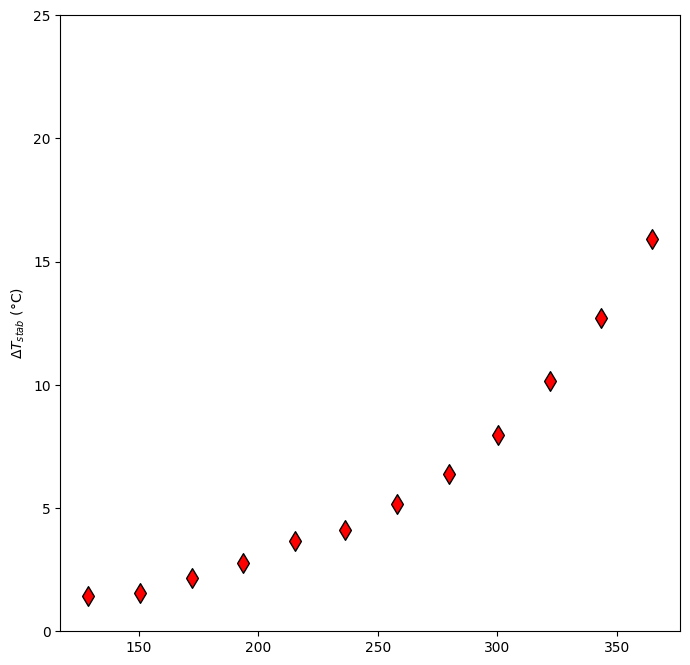

In [5]:
df_one["UTS"] = 430
df_one["Maximum stress"] = (df_one["UTS"] * df_one["Maximum stress(% UTS)"]) / 100
df_one

plt.figure(figsize=(8, 8))
plt.scatter(df_one["Maximum stress"], df_one["Temperature Stab"],c='red', marker='d', s=100, edgecolors='k')
plt.ylim(0, 25)
plt.fontsize = 18
plt.ylabel("$\Delta T_{stab}$ (°C)")
plt.plot()

Splitting the data into training and testing for the first part of our ML/DL Pipeline.
We do a 50-50 random split based on our domain knowledge of data distribution 

In [6]:
train_dfone = df_one.sample(frac = 0.5, random_state=40)
test_dfone = df_one.drop(train_dfone.index).reset_index(drop=True)
test_dfone

,Maximum stress(% UTS),Temperature Stab,UTS,Maximum stress
0,29.986,1.438,430,128.9398
1,40.031,2.146,430,172.1333
2,54.951,4.094,430,236.2893
3,60.036,5.149,430,258.1548
4,65.050,6.363,430,279.7150
5,69.853,7.975,430,300.3679


In [7]:
train_dfone = train_dfone.reset_index(drop=True)
train_dfone

,Maximum stress(% UTS),Temperature Stab,UTS,Maximum stress
0,79.858,12.705,430,343.3894
1,74.926,10.168,430,322.1818
2,84.852,15.931,430,364.8636
3,45.050,2.777,430,193.7150
4,50.068,3.647,430,215.2924
5,35.011,1.567,430,150.5473


In [8]:
train_dfone.columns

Index(['Maximum stress(% UTS)', 'Temperature Stab', 'UTS', 'Maximum stress'], dtype='object')

In [9]:
#Fatigue Limit in terms of maximum stress %
delta_fl = 64

Data augmentation is a technique used to artificially increase the size and diversity of a training dataset by applying various transformations to existing data samples. This helps to improve the performance and generalization ability of machine learning models, particularly when dealing with limited or imbalanced datasets

We augment our data based on finding the right curve fiting of the datapoints. We induce a slight noise to the points and thus get a distribution even where there is not enough data. Following is the function to carry out the data augmentation process

<>:92: SyntaxWarning: invalid escape sequence '\D'
<>:92: SyntaxWarning: invalid escape sequence '\D'
/var/folders/dl/_w72qrpj6gs0p_2yyrq_pcdr0000gn/T/ipykernel_10914/1591474971.py:92: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("$\Delta T_{stab}$ (°C)")


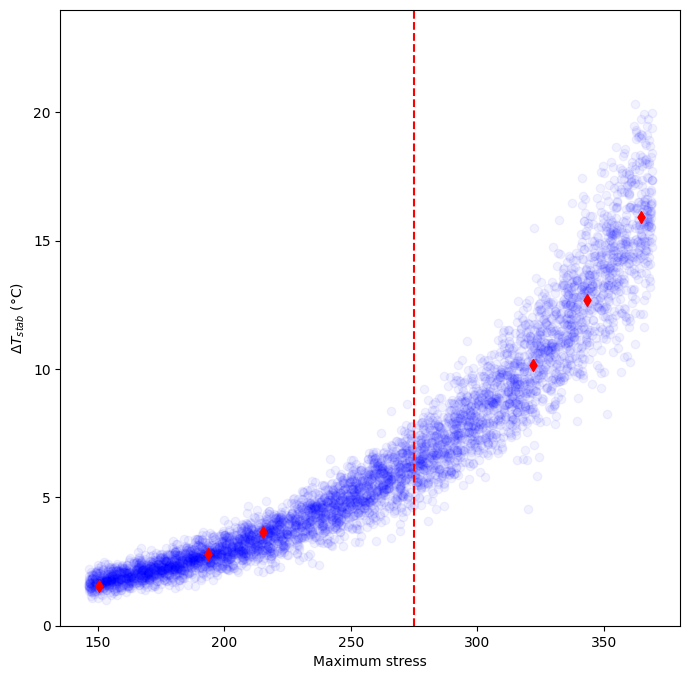

In [10]:
from scipy.optimize import curve_fit

def augment_SN_MC_global(
    train_SN,
    n_samples=5000,
    noise_level=0.15,  
    rng_seed=42
):
    rng = np.random.default_rng(rng_seed)
    
    s_real = train_SN["Maximum stress(% UTS)"].to_numpy(float)
    t_real = train_SN["Temperature Stab"].to_numpy(float)

    def physics_model(x, a, b, c):
        return a * np.exp(b * x) + c

    p0 = [0.01, 0.05, 0] 
    
    try:
        popt, _ = curve_fit(physics_model, s_real, t_real, p0=p0, maxfev=10000)
    except RuntimeError:
        print("Exponential fit failed, falling back to Polynomial (deg 3)")
        z = np.polyfit(s_real, t_real, 3)
        physics_model = lambda x, *args: np.polyval(z, x)
        popt = []

    #Monte Carlo Simulation
    s_min, s_max = s_real.min(), s_real.max()
    s_range = s_max - s_min
    mc_stress = rng.uniform(s_min - 0.02*s_range, s_max + 0.02*s_range, n_samples)
    
    if len(popt) > 0:
        mc_temp_mean = physics_model(mc_stress, *popt)
    else:
        mc_temp_mean = physics_model(mc_stress)

    # B. Add Heteroscedastic Noise (Noise scales with magnitude)
    # Real data shows: Low Temp = Low Noise, High Temp = High Noise
    
    abs_noise = 0.05 # Minimum noise (degrees C)
    rel_noise = mc_temp_mean * noise_level 
    
    sigma_noise = abs_noise + rel_noise
    
    mc_temp = mc_temp_mean + rng.normal(0, sigma_noise)
    
    # Temperature cannot be negative
    mc_temp = np.maximum(mc_temp, 0.0) 
    # Stress cannot be negative
    mc_stress = np.maximum(mc_stress, 0.0)

    # 5. Package Data
    aug = pd.DataFrame({
        "Maximum stress(%UTS)": mc_stress,
        "Maximum stress": (mc_stress * 430) / 100,
        "Temp stabilisation":   mc_temp,
        "Source":               "augmented_MC",
        "sample_weight":        np.ones(n_samples)
    })
    
    real = pd.DataFrame({
        "Maximum stress(%UTS)": s_real,
        "Maximum stress": (s_real * 430) / 100,
        "Temp stabilisation":   t_real,
        "Source":               "real",
        "sample_weight":        np.ones(len(s_real))
    })
    
    combined = pd.concat([aug, real], ignore_index=True)
    
    return combined, aug, real, popt


combined_df, aug_df, real_df, params = augment_SN_MC_global(train_dfone, n_samples=5000, noise_level=0.12)

plt.figure(figsize=(8, 8))
plt.scatter(aug_df["Maximum stress"], aug_df["Temp stabilisation"], 
            c='blue', alpha=0.05, label='MC Augmented (Global)')
plt.scatter(real_df["Maximum stress"], real_df["Temp stabilisation"], 
            c='red', marker='d', label='Train Real')

# Plot the fitted trendline to verify
#x_trend = np.linspace(real_df["Maximum stress"].min(), real_df["Maximum stress"].max(), 100)
#def func(x, a, b, c): return a * np.exp(b * x) + c
#if len(params) > 0:
#    plt.plot(x_trend, func(x_trend, *params), 'k--', label="fitted trend")

plt.xlabel("Maximum stress")
#plt.xlim(30,90)
plt.ylim(0, 24)
plt.fontsize = 18
plt.ylabel("$\Delta T_{stab}$ (°C)")
plt.axvline(delta_fl*4.3, color="red", ls="--", label="Fatigue strength")
#plt.title("Monte Carlo Augmentation")
#plt.legend()
plt.show()

The above graph gives us a good visualisation for how the augmented data looks like

In [11]:
combined_df

,Maximum stress(%UTS),Maximum stress,Temp stabilisation,Source,sample_weight
0,74.131913,318.767227,8.570181,augmented_MC,1.0
1,56.763286,244.082129,4.300943,augmented_MC,1.0
2,78.519294,337.632965,12.437774,augmented_MC,1.0
3,70.162001,301.696603,7.690509,augmented_MC,1.0
4,38.895829,167.252064,1.987423,augmented_MC,1.0
...,...,...,...,...,...
5001,74.926000,322.181800,10.168000,real,1.0
5002,84.852000,364.863600,15.931000,real,1.0
5003,45.050000,193.715000,2.777000,real,1.0
5004,50.068000,215.292400,3.647000,real,1.0


Final Distribution of the Augmented values plotted with the real values 

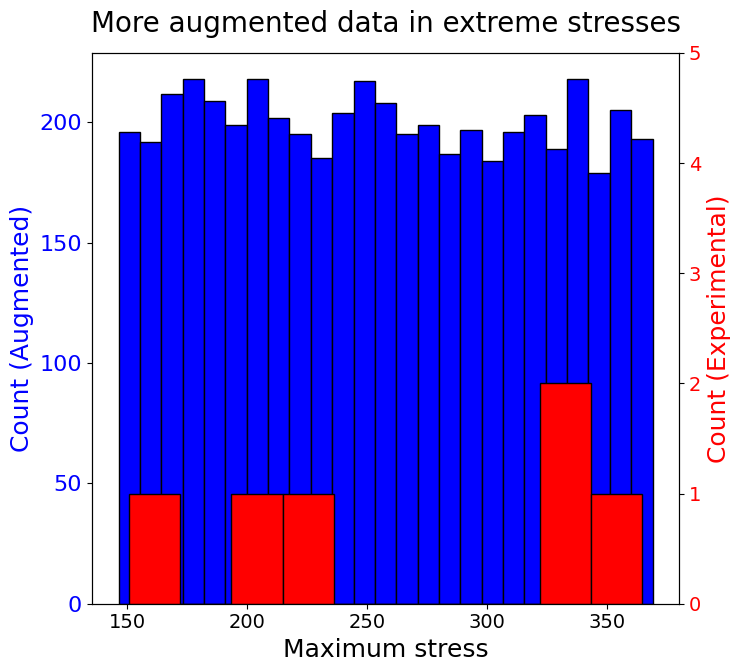

In [12]:
plt.rcParams.update({'font.size': 16})

fig, ax1 = plt.subplots(figsize=(8, 7))

ax1.hist(aug_df["Maximum stress"], bins=25, alpha=1,
         label="Augmented", color="b", edgecolor="k")
ax1.set_xlabel("Maximum stress", fontsize=18)
ax1.set_ylabel("Count (Augmented)", color="b", fontsize=18)
ax1.tick_params(axis='y', labelcolor='b')
ax1.tick_params(axis='x', labelsize=14)


ax2 = ax1.twinx()
ax2.hist(real_df["Maximum stress"], bins=10, alpha=1,
         label="Experimental", color="r", edgecolor="k")
ax2.set_ylabel("Count (Experimental)", color="r", fontsize=18)
ax2.tick_params(axis='y', labelcolor='r', labelsize=14)

plt.title("More augmented data in extreme stresses", fontsize=20, pad=15)
#fig.legend(loc="upper right", bbox_to_anchor=(1,1),
#           bbox_transform=ax1.transAxes, fontsize=14)

plt.tight_layout()
plt.ylim(0,5)
plt.show()

We will now use this Augmented dataset to build an XGBoost Model that will predict Temperature for a given stress value. This model is important because a good prediction here will allow us to map these temperature values for the corresponding stress values in the stress vs number of cycles dataset 

In [13]:
test_dfone = test_dfone.rename(columns={"Maximum stress(% UTS)": "Maximum stress(%UTS)", "Temperature Stab":"Temp stabilisation"})
test_dfone

,Maximum stress(%UTS),Temp stabilisation,UTS,Maximum stress
0,29.986,1.438,430,128.9398
1,40.031,2.146,430,172.1333
2,54.951,4.094,430,236.2893
3,60.036,5.149,430,258.1548
4,65.050,6.363,430,279.7150
5,69.853,7.975,430,300.3679


[]

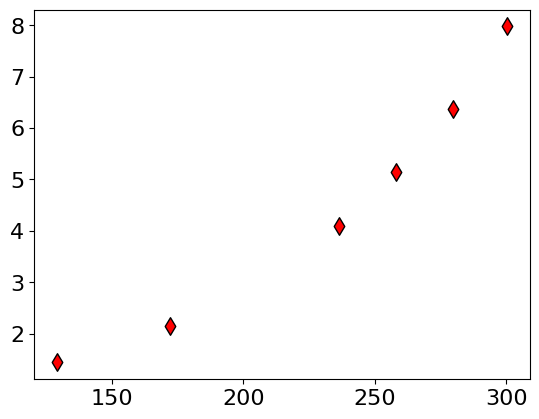

In [14]:
plt.scatter(test_dfone["Maximum stress"], test_dfone["Temp stabilisation"],c='red', marker='d', s=80, edgecolors='k')
plt.plot()

The rapid growth of data science and computational power has led to the rise of machine learning (ML) as a powerful tool in various fields, including the modeling of composite materials . Machine learning also offers great potential for efficient and accurate prediction of the fatigue strength and life of composite materials. Linear regression, random forest regression, support vector regression, and artificial neural networks, among others, are commonly used ML-based regression algorithms for fatigue life prediction.

Defining the Input/Output features of the Model 

In [15]:
features = ["Maximum stress"]

X_train = combined_df[features]
X_test = test_dfone[features]
y_train = combined_df["Temp stabilisation"]
y_test = test_dfone["Temp stabilisation"]

Model Architecture of an XGBoost 

In [16]:
w_train = combined_df["sample_weight"].to_numpy()
model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model_xgb.fit(X_train, y_train, sample_weight=w_train)
new_preds = model_xgb.predict(X_test)

r2 = r2_score(y_test, new_preds)
#As we can see, the r2 value is excellent. This allows us to use this model for our further predictions
print(r2)

0.9866986838921344


Following is the plot to show actual vs predicted for the trained model 

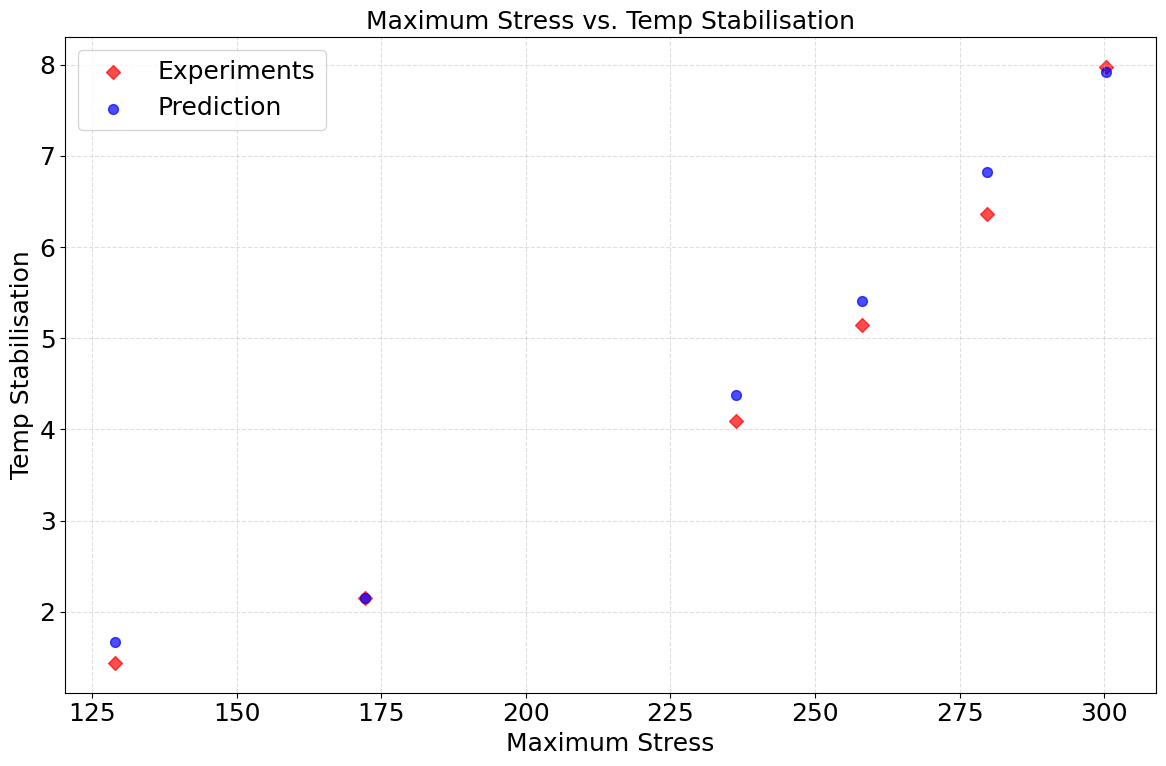

In [17]:
plt.rc('font', size=18) 

plt.figure(figsize=(12, 8))

plt.scatter(
    X_test["Maximum stress"], 
    y_test, 
    color='red', 
    label='Experiments', 
    marker='D', 
    s=50,    
    alpha=0.7
)

plt.scatter(
    X_test["Maximum stress"], 
    new_preds, 
    color='blue', 
    label='Prediction', 
    marker='o', 
    s=50, 
    alpha=0.7
)

plt.title('Maximum Stress vs. Temp Stabilisation', fontsize=18)
plt.xlabel('Maximum Stress', fontsize=18)
plt.ylabel('Temp Stabilisation', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

As we can see, our approach to the augmentation with a curve fit allows us to predict values with a noise even in the scarcity of data points. This allows us to get a very good r2 value concluding our model building 

Importing our stress vs number of cycles dataset 

In [ ]:
file = r"StressvsNumberofcycles.xlsx"

df = pd.read_excel(file)

df.to_csv("StressvsNumberofcycles.csv", index=False)

In [19]:
df

,Max applied stress(%UTS),Number of cycles,Real/Fit data
0,0.849,2219.00,Real
1,0.850,2682.50,Real
2,0.798,9998.16,Real
3,0.797,12664.27,Real
4,0.797,16044.27,Real
5,0.749,98330.90,Real
6,0.748,110659.80,Real
7,0.701,1168773.00,Real
8,0.699,1379018.00,Real
9,0.698,1551922.00,Real


In [20]:
df["log cycles"] = np.log10(df["Number of cycles "])

Adding necessary feature columns 

In [21]:
df["UTS"] = 430
df["Max applied stress(%UTS)"] = df["Max applied stress(%UTS)"] * 100
df["Maximum stress"] = (df["UTS"] * df["Max applied stress(%UTS)"]) / 100
df

,Max applied stress(%UTS),Number of cycles,Real/Fit data,log cycles,UTS,Maximum stress
0,84.9,2219.00,Real,3.346157,430,365.07
1,85.0,2682.50,Real,3.428540,430,365.50
2,79.8,9998.16,Real,3.999920,430,343.14
3,79.7,12664.27,Real,4.102580,430,342.71
4,79.7,16044.27,Real,4.205320,430,342.71
5,74.9,98330.90,Real,4.992690,430,322.07
6,74.8,110659.80,Real,5.043990,430,321.64
7,70.1,1168773.00,Real,6.067730,430,301.43
8,69.9,1379018.00,Real,6.139570,430,300.57
9,69.8,1551922.00,Real,6.190870,430,300.14


The following scatter plot shows the how the S-N Curve looks like for the data

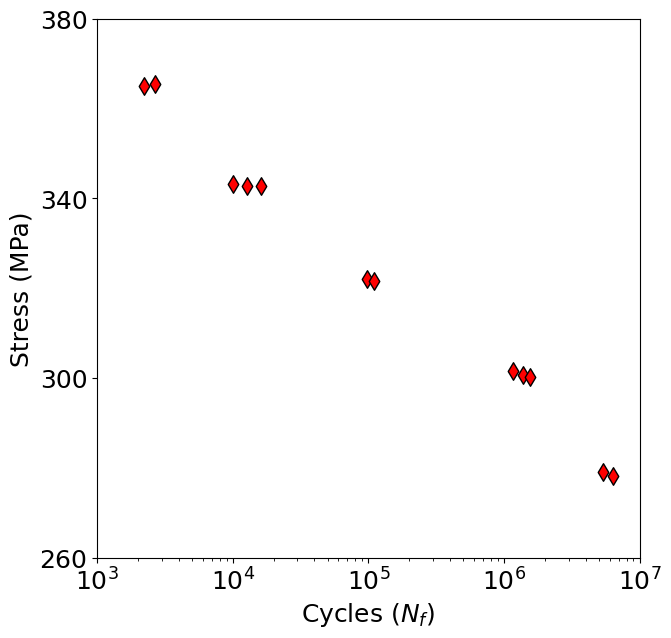

In [22]:
plt.figure(figsize=(7, 7))
plt.xscale('log')
plt.scatter(df["Number of cycles "], df["Maximum stress"],c='red', marker='d', s=80, edgecolors='k')
plt.xlabel('Cycles ($N_f$)', fontsize=18)
plt.ylabel('Stress (MPa)', fontsize=18)
plt.xlim(1e3, 1e7)
plt.yticks([260, 300, 340, 380])
plt.ylim(260,380)
plt.show()

In [23]:
df.columns

Index(['Max applied stress(%UTS)', 'Number of cycles ', 'Real/Fit data',
       'log cycles', 'UTS', 'Maximum stress'],
      dtype='object')

In [24]:
df = df.rename(columns={"Max applied stress(%UTS)": "Maximum stress(%UTS)", "Number of cycles ": "Number of cycles", "Real/Fit data": "Source"})
df

,Maximum stress(%UTS),Number of cycles,Source,log cycles,UTS,Maximum stress
0,84.9,2219.00,Real,3.346157,430,365.07
1,85.0,2682.50,Real,3.428540,430,365.50
2,79.8,9998.16,Real,3.999920,430,343.14
3,79.7,12664.27,Real,4.102580,430,342.71
4,79.7,16044.27,Real,4.205320,430,342.71
5,74.9,98330.90,Real,4.992690,430,322.07
6,74.8,110659.80,Real,5.043990,430,321.64
7,70.1,1168773.00,Real,6.067730,430,301.43
8,69.9,1379018.00,Real,6.139570,430,300.57
9,69.8,1551922.00,Real,6.190870,430,300.14


Finding the optimal K Fold Cross Validation Strategy 

In [25]:
df

,Maximum stress(%UTS),Number of cycles,Source,log cycles,UTS,Maximum stress
0,84.9,2219.00,Real,3.346157,430,365.07
1,85.0,2682.50,Real,3.428540,430,365.50
2,79.8,9998.16,Real,3.999920,430,343.14
3,79.7,12664.27,Real,4.102580,430,342.71
4,79.7,16044.27,Real,4.205320,430,342.71
5,74.9,98330.90,Real,4.992690,430,322.07
6,74.8,110659.80,Real,5.043990,430,321.64
7,70.1,1168773.00,Real,6.067730,430,301.43
8,69.9,1379018.00,Real,6.139570,430,300.57
9,69.8,1551922.00,Real,6.190870,430,300.14


Following is the function to plot out the derivatives graph. All of these helper plotting functions are utilised to build the necessary graphs to showcase how the predictions and results look like 

In [26]:
def check_derivatives(model, scaler, device):
    """Visualizes if the model respects the physics constraint (dLife/dStress < 0)"""
    stress_range = np.linspace(200, 600, 100).reshape(-1, 1)
    temp_range = np.zeros_like(stress_range) 
    
    X_grid = np.column_stack([stress_range, temp_range])
    X_grid_s = scaler.transform(X_grid)
    X_tensor = torch.tensor(X_grid_s, dtype=torch.float32, device=device, requires_grad=True)
    
    model.eval()
    logN_pred = model(X_tensor)
    grads = torch.autograd.grad(logN_pred, X_tensor, torch.ones_like(logN_pred), create_graph=True)[0]
    dLogN_dStress = grads[:, 0].cpu().detach().numpy() 
    
    plt.figure(figsize=(6, 4))
    plt.plot(stress_range, dLogN_dStress, color='purple', lw=2)
    plt.axhline(0, color='red', linestyle='--', label='Physics Limit (0)')
    plt.fill_between(stress_range.flatten(), dLogN_dStress, 0, where=(dLogN_dStress > 0), color='red', alpha=0.3, label='Violation')
    plt.fill_between(stress_range.flatten(), dLogN_dStress, 0, where=(dLogN_dStress < 0), color='green', alpha=0.1, label='Valid')
    plt.ylabel("Gradient (dLife/dStress)")
    plt.xlabel("Stress")
    plt.title("Physics Check: Is the derivative negative?")
    plt.legend()
    plt.show()

Model Definition and Augmentation Function 

In this approach we use augmentation function based on the extreme values. We use the maximum and minimum values in the dataset and extrapolate points in between these 2 data points based on the 95% confidence bound.
In order to make sure we don't do any data leakage, the augmentation only happens when we do the splitting of training and testing in the K fold cross validation step 

We propose a Physics Informed Neural Network for effective Fatigue life prediction. PINNs in general are architectures that can embed the knowledge of any physical laws that govern a given data-set in the learning process. The prior knowledge of general physical laws acts in the training of neural networks (NNs) as a regularization agent that limits the space of admissible solutions, increasing the generalizability of the function approximation

In [27]:
device = torch.device("mps" if torch.backends.mps.is_available() else 
                      "cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

class LifeNet(nn.Module):
    def __init__(self, in_dim=2, hidden=64, out_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, out_dim)
        )
        
    def forward(self, x):
        return self.net(x)

def physics_loss(model, X_phys):
    """Enforces: Life decreases as Stress or Temp increases."""
    Xp = X_phys.clone().detach().requires_grad_(True)
    logN_pred = model(Xp)
    grads = torch.autograd.grad(logN_pred, Xp, torch.ones_like(logN_pred), create_graph=True)[0]
    
    # penalty = ReLU( dLogN/dStress ) + ReLU( dLogN/dTemp )
    penalty = torch.relu(grads[:, 0:1]) + torch.relu(grads[:, 1:2])
    return torch.mean(penalty**2)

# --- 3. AUGMENTATION ENGINE ---
def augment_training_data(df, n_aug=1000):
    """Generates synthetic data along the 95% bound of the stress-life curve."""
    # Find extremes
    p_min = df.loc[df["Maximum stress"].idxmin()]
    p_max = df.loc[df["Maximum stress"].idxmax()]
    
    slope = (p_max["Maximum stress"] - p_min["Maximum stress"]) / \
            (p_max["log cycles"] - p_min["log cycles"]) if p_max["log cycles"] != p_min["log cycles"] else 0
    intercept = p_max["Maximum stress"] - slope * p_max["log cycles"]
    
    # Generate Synthetic Points
    x_synth = np.linspace(df["log cycles"].min(), df["log cycles"].max(), n_aug)
    y_line = slope * x_synth + intercept
    y_synth = np.random.uniform(y_line - 5.0, y_line + 5.0) # +/- 5% variation
    
    df_aug = pd.DataFrame({
        "log cycles": x_synth,
        "Maximum stress": y_synth,
        "Number of cycles": 10**x_synth,
        "Source": "augmented",
        "UTS": 430,
        "Maximum stress(%UTS)": (y_synth * 100)/ 430
    })
    
    return pd.concat([df, df_aug], ignore_index=True)

def train_and_evaluate_fold(train_df, test_df, xgb_model, epochs=500, verbose=False, plot_diagnostics=False):
    """
    Encapsulates the entire process for ONE fold:
    Augment -> Predict Temp -> Scale -> Train PINN -> Evaluate
    """
    # A. Augment (Only Training Data)
    train_aug = augment_training_data(train_df)
    
    train_aug["Predicted Temperature"] = model_xgb.predict(train_aug[["Maximum stress"]])
    test_df = test_df.copy() 
    test_df["Predicted Temperature"] = model_xgb.predict(test_df[["Maximum stress"]])
    
    X_train = train_aug[["Maximum stress", "Predicted Temperature"]].values
    y_train = train_aug["log cycles"].values.reshape(-1, 1)
    X_test  = test_df[["Maximum stress", "Predicted Temperature"]].values
    y_test  = test_df["log cycles"].values.reshape(-1, 1)
    
    # Scale
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    
    # To GPU
    X_tr_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
    y_tr_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    X_te_t = torch.tensor(X_test_s, dtype=torch.float32, device=device)
    
    model = LifeNet(hidden=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    
    history_data = [] 
    history_phys = []

    model.train()
    for ep in range(epochs):
        optimizer.zero_grad()
        pred = model(X_tr_t)
        loss_d = nn.MSELoss()(pred, y_tr_t)
        loss_p = physics_loss(model, X_tr_t)
        loss = loss_d + 0.1 * loss_p
        loss.backward()
        optimizer.step()
        
        history_data.append(loss_d.item())
        history_phys.append(loss_p.item())
    
    if plot_diagnostics:
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.plot(history_data, label='Data Loss (MSE)')
        plt.plot(history_phys, label='Physics Loss')
        plt.yscale('log')
        plt.legend()
        plt.title("Is the model fighting physics?")
        
        plt.subplot(1, 2, 2)
        X_viz = X_tr_t.clone().detach().requires_grad_(True)
        pred_viz = model(X_viz)
        
        grads = torch.autograd.grad(
            outputs=pred_viz, 
            inputs=X_viz, 
            grad_outputs=torch.ones_like(pred_viz), 
            create_graph=False 
        )[0]
        
        stress_grads = grads[:, 0].cpu().detach().numpy()
        plt.hist(stress_grads, bins=30, color='purple', alpha=0.7)
        plt.axvline(0, color='red', linestyle='--')
        plt.xlabel("dLife/dStress Gradient")
        plt.title("Gradients (Should be < 0)")
        plt.tight_layout()
        plt.show()
        
        check_derivatives(model, scaler, device)
    model.eval()
    with torch.no_grad():
        logN_pred = model(X_te_t).cpu().numpy()
    
    rmse = np.sqrt(np.mean((logN_pred - y_test)**2))
    return rmse

Running on: mps


In [28]:
from sklearn.model_selection import KFold, RepeatedKFold

Finding the optimal K Fold Cross Validation Strategy

Here is the function definition for the K fold validation check. The function goes through the entire sample size and finds the most optimal K value. Each fold runs for an approximate arbitrary number of epochs times. We implement a K fold strategy where we run the model from K = 2 to K = N - 1, N being the number of samples. This allows us to find the best validation strategy for our dataset

Starting Exhaustive Stability Analysis (N=12 samples)...
Processing K=2... Mean RMSE: 0.1538
Processing K=3... Mean RMSE: 0.1627
Processing K=4... Mean RMSE: 0.1509
Processing K=5... Mean RMSE: 0.1555
Processing K=6... Mean RMSE: 0.1538
Processing K=7... Mean RMSE: 0.1546
Processing K=8... Mean RMSE: 0.1593
Processing K=9... Mean RMSE: 0.1487
Processing K=10... Mean RMSE: 0.1493
Processing K=11... Mean RMSE: 0.1486
Processing K=12... Mean RMSE: 0.1438


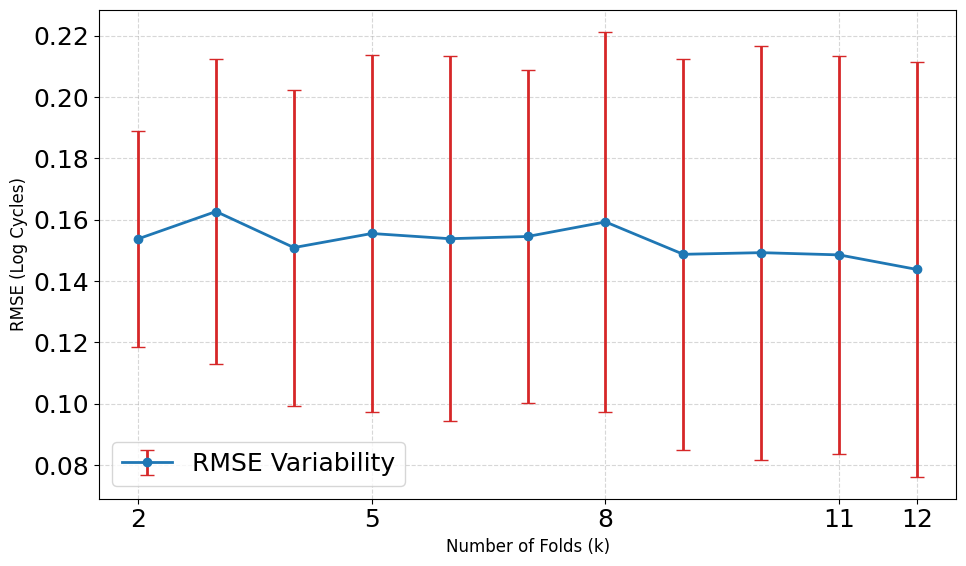

In [ ]:
np.random.seed(42)

def find_optimal_k(df, model_xgb, n_repeats=5):
    """
    Runs repeated CV for ALL possible K values (from 2 to N).
    Best for small datasets (N < 50).
    """
    N = len(df)
    k_candidates = range(2, N + 1) 
    
    results = {k: [] for k in k_candidates}
    
    print(f"Starting Exhaustive Stability Analysis (N={N} samples)...")
    
    for k in k_candidates:
        print(f"Processing K={k}...", end=" ")
        
        rkf = RepeatedKFold(n_splits=k, n_repeats=n_repeats, random_state=42)
        
        k_scores = []
        
        for train_idx, test_idx in rkf.split(df):
            train_fold = df.iloc[train_idx].copy()
            test_fold  = df.iloc[test_idx].copy()
            
            rmse = train_and_evaluate_fold(train_fold, test_fold, model_xgb, epochs=500)
            k_scores.append(rmse)
        
        results[k] = k_scores
        print(f"Mean RMSE: {np.mean(k_scores):.4f}")
        
    return results

stats = find_optimal_k(df, model_xgb, n_repeats=3)

def plot_stability(stats, tick_step=3):
    means = [np.mean(stats[k]) for k in stats]
    stds  = [np.std(stats[k]) for k in stats]
    ks    = list(stats.keys())
    

    plt.figure(figsize=(10, 6))
    
    plt.errorbar(
        ks, means, yerr=stds, fmt='-o', capsize=5,
        color='tab:blue', ecolor='tab:red',
        linewidth=2, label='RMSE Variability'
    )

    plt.xlabel("Number of Folds (k)", fontsize=12)
    plt.ylabel("RMSE (Log Cycles)", fontsize=12)

    tick_positions = ks[::tick_step]
    if ks[-1] not in tick_positions:
        tick_positions.append(ks[-1])

    plt.xticks(tick_positions)

    plt.grid(True, linestyle='--', alpha=0.5)

    plt.legend()
    plt.tight_layout()
    plt.show()



# --- PLOTTING(Continuous K) ---
# def plot_stability(stats):
#     means = [np.mean(stats[k]) for k in stats]
#     stds  = [np.std(stats[k]) for k in stats]
#     ks    = list(stats.keys())

#     plt.figure(figsize=(10, 6))
    
#     # Error Bar Plot
#     plt.errorbar(ks, means, yerr=stds, fmt='-o', capsize=5, 
#                  color='tab:blue', ecolor='tab:red', linewidth=2, label='RMSE Variability')
    
#     plt.xlabel("Number of Folds (k)", fontsize=12)
#     plt.ylabel("RMSE (Log Cycles)", fontsize=12)
#     plt.title(f"Stability Analysis (K=2 to {max(ks)})", fontsize=14)
    
#     # Ensure x-axis shows integers only
#     plt.xticks(ks) 
#     plt.grid(True, linestyle='--', alpha=0.5)
    
#     # best_k_idx = np.argmin(stds)
#     # best_k = ks[best_k_idx]
#     # plt.annotate(f'Most Stable (k={best_k})', 
#     #              xy=(best_k, means[best_k_idx]), 
#     #              xytext=(80, 130),  # move the text 40 points above the marker
#     #             textcoords='offset points',
#     #             ha='center',
#     #             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8)
#     # )
#     plt.legend()
#     plt.show()
    
plot_stability(stats)

Creating a table with all the possible K folds and the corresponding RMSE Values that allow us to choose the correct fold

In [35]:
def make_k_table(stats):
    rows = []
    for k, scores in stats.items():
        rows.append({
            "k": k,
            "RMSE_mean": float(np.mean(scores)),
            "RMSE_std":  float(np.std(scores)),   # variability / s.d.
        })
    return pd.DataFrame(rows).sort_values("k").reset_index(drop=True)

k_table = make_k_table(stats)
print(k_table)

     k  RMSE_mean  RMSE_std
0    2   0.153772  0.035200
1    3   0.162699  0.049836
2    4   0.150929  0.051542
3    5   0.155526  0.058137
4    6   0.153829  0.059555
5    7   0.154550  0.054344
6    8   0.159311  0.061872
7    9   0.148740  0.063785
8   10   0.149279  0.067518
9   11   0.148552  0.064992
10  12   0.143790  0.067531


Plotting

Function to visualize the Augmented data within a representative fold

In [29]:
def visualize_fold_augmentation(df_combined, fold_idx):
    """
    Plots the specific augmentation strategy for a single fold.
    """
    real = df_combined[df_combined["Source"] != "augmented"]
    synth = df_combined[df_combined["Source"] == "augmented"]
    
    plt.figure(figsize=(8, 8))
    
    # 1. Plot Synthetic Data
    plt.scatter(synth["log cycles"], synth["Maximum stress"], 
                c='tab:blue', alpha=0.15, s=15, label='Augmented Data')
    
    # 2. Plot Real Training Data
    plt.scatter(real["log cycles"], real["Maximum stress"], marker='d',
                c='red', s=80, edgecolors='k', linewidth=1.5, zorder=10, label='Real Training Data')
    
    p_min = real.loc[real["Maximum stress"].idxmin()]
    p_max = real.loc[real["Maximum stress"].idxmax()]
    
    if p_max["log cycles"] != p_min["log cycles"]:
        slope = (p_max["Maximum stress"] - p_min["Maximum stress"]) / (p_max["log cycles"] - p_min["log cycles"])
    else:
        slope = 0
    intercept = p_max["Maximum stress"] - slope * p_max["log cycles"]
    
    x_line = np.linspace(real["log cycles"].min(), real["log cycles"].max(), 100)
    y_center = slope * x_line + intercept
    
    plt.plot(x_line, y_center, 'k--', linewidth=2, label='Extrapolation Fit')
    plt.plot(x_line, y_center + 5.0, 'r--', linewidth=1, label='95% Bounds') # +5% UTS
    plt.plot(x_line, y_center - 5.0, 'r--', linewidth=1)
    
    plt.xlabel(r"Log Cycles ($\log_{10}N$)")
    plt.ylabel("Maximum Stress (MPa)")
    plt.title(f"Fold {fold_idx+1} Data Augmentation Strategy")
    plt.legend(loc='upper right', frameon=True)
    plt.grid(True, linestyle='--', alpha=0.4)
    ax = plt.gca()
    ax.set_yticks([250, 300, 350, 400])
    ax.set_xticks([3, 4, 5, 6, 7])                     # positions in log space
    ax.set_xticklabels([r'$10^3$', r'$10^4$', r'$10^5$', r'$10^6$', r'$10^7$'])  # show as 10^x
    plt.show()

In [30]:
def plot_augmented_stress_vs_temp(train_aug):
    """
    Plots Stress vs Predicted Temperature.
    Size: 8x8
    """
    synth = train_aug[train_aug["Source"] == "augmented"]
    

    plt.figure(figsize=(8, 8))
    
    plt.scatter(synth["Maximum stress"], synth["Predicted Temperature"], 
                c='tab:blue', marker='o', s=50, alpha=0.3, label='Trained XGBoost Predictions')
    
    plt.scatter(df_one["Maximum stress"], df_one["Temperature Stab"], 
                c='red', marker='d', s=120, edgecolors='k', linewidth=1.5, zorder=10, label='Experimental Data')
    
    plt.ylabel("Predicted Temperature (°C)", fontsize=18)
    plt.xlabel("Maximum Stress (MPa)", fontsize=18)
    plt.title("Stress vs. Predicted Temperature", fontsize=18)
    
    plt.legend(loc='upper left', frameon=True, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.4)
    
    ax = plt.gca()
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.tick_params(axis='both', which='minor', labelsize=18)
    plt.axvline(delta_fl*4.3, color="red", ls="--", label="Fatigue strength")
    
    plt.tight_layout()
    plt.show()

Evaluation Metrics function. The evaluation metrics used in the analysis are as follows:
1. R^2; R squared ; Higher the value, closer to 1 is better
2. RMSE; Root mean squared error ; Lower the value the better

In [31]:
from sklearn.metrics import r2_score

def print_model_report_card(y_true, y_pred):
    """
    Calculates relative metrics to contextualize RMSE.
    Expects y_true and y_pred to be in Log10 scale.
    """
    # 1. Absolute RMSE
    rmse = np.sqrt(np.mean((y_pred - y_true)**2))
    
    # 2. Factor of Error (Fatigue Specific)
    factor_err = 10**rmse
    
    # 3. Normalized RMSE (Relative to Range)
    data_range = np.max(y_true) - np.min(y_true)
    nrmse = (rmse / data_range) * 100
    
    # 4. R2 Score (Variance Explained)
    r2 = r2_score(y_true, y_pred)
    
    print("-" * 30)
    print("MODEL PERFORMANCE REPORT")
    print("-" * 30)
    print(f"RMSE (Log Units):      {rmse:.4f}")
    print(f"Avg Error Factor:      {factor_err:.2f}x (Life prediction is within factor of {factor_err:.1f})")
    print(f"Normalized RMSE:       {nrmse:.2f}% of data range")
    print(f"R² Score:              {r2:.4f}")
    print("-" * 30)
    
    if factor_err < 2.0:
        print("VERDICT: EXCELLENT (Within standard experimental scatter)")
    elif factor_err < 3.0:
        print("VERDICT: ACCEPTABLE (Standard for high-scatter)")
    else:
        print("VERDICT: HIGH ERROR (Model may be underfitting)")


In the following function execution we see a graph on the upper right part for the comparison between the physics loss and the data loss. The graph reflects the training phase, where the model is updating its internal weights while going through the training set. 
As we see from the graph, both the physics loss and data loss is going down. It means our data is physically consistent with the constraints. 

Updated Functions for training the final PINN model with the correct K fold and data augmentation strategy

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

def run_final_pipeline(
    df,
    xgb_model,
    best_k=2,
    device=None,
    epochs=1000,
    lr=0.002,
    lam_phys=0.1,
    do_plots_first_fold=True
):
    """
    Trains a K-fold ensemble of PINNs and stores:
      - loss histories (data, phys, phys-share, TEST MSE)
      - per-point physics violation on the augmented training set
      - training fold inputs (stress/temp/logN) for analysis
      - per-fold TRAIN/TEST metrics (on log10 life): MSE, RMSE, MAE, R2

    Returns:
      ensemble_models, metrics_table
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available()
                              else "mps" if torch.backends.mps.is_available()
                              else "cpu")

    print(f"\nTraining Final Ensemble with K={best_k}")
    kf = KFold(n_splits=best_k, shuffle=True, random_state=42)

    ensemble_models = []
    metrics_rows = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(df)):
        # -------------------------
        # 1) Split
        # -------------------------
        train_fold = df.iloc[train_idx].copy()
        test_fold  = df.iloc[test_idx].copy()
        train_fold["Source"] = "real"

        if "Run Out" in train_fold.columns:
            train_fold = train_fold[train_fold["Run Out"] != "yes"].copy()
        if "Run Out" in test_fold.columns:
            test_fold = test_fold[test_fold["Run Out"] != "yes"].copy()

        # -------------------------
        # 2) Augment training fold
        # -------------------------
        train_aug = augment_training_data(train_fold)

        if "Run Out" in train_aug.columns:
            train_aug = train_aug[train_aug["Run Out"] != "yes"].copy()

        if do_plots_first_fold and fold == 0:
            print("Visualizing Augmentation for Fold 1...")
            visualize_fold_augmentation(train_aug, fold)

        # -------------------------
        # 3) Predict temperature (train + test)
        # -------------------------
        train_aug["Predicted Temperature"] = xgb_model.predict(train_aug[["Maximum stress"]])
        if not test_fold.empty:
            test_fold["Predicted Temperature"] = xgb_model.predict(test_fold[["Maximum stress"]])

        if do_plots_first_fold and fold == 0:
            print("Visualizing Stress vs. Predicted Temperature for Fold 1...")
            plot_augmented_stress_vs_temp(train_aug)

        # -------------------------
        # 4) Prepare TRAIN tensors
        # -------------------------
        X_train = train_aug[["Maximum stress", "Predicted Temperature"]].values
        y_train = train_aug["log cycles"].values.reshape(-1, 1)  # log10(N)

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)

        X_tr_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
        y_tr_t = torch.tensor(y_train, dtype=torch.float32, device=device)
        
        X_tr_t.requires_grad_(True)

        # -------------------------
        # 5) Prepare TEST tensors (for validation tracking)
        # -------------------------
        X_te_t_val = None
        y_te_t_val = None
        if not test_fold.empty:
            X_test_val = test_fold[["Maximum stress", "Predicted Temperature"]].values
            y_test_val = test_fold["log cycles"].values.reshape(-1, 1)
            X_test_val_s = scaler.transform(X_test_val)
            
            X_te_t_val = torch.tensor(X_test_val_s, dtype=torch.float32, device=device)
            y_te_t_val = torch.tensor(y_test_val, dtype=torch.float32, device=device)

        # -------------------------
        # 6) Train PINN
        # -------------------------
        model = LifeNet(hidden=64).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        hist_d, hist_p, hist_share = [], [], []
        hist_test = [] 

        model.train()
        for _ in range(epochs):
            optimizer.zero_grad()
            pred = model(X_tr_t)

            loss_d = nn.MSELoss()(pred, y_tr_t)
            loss_p = physics_loss(model, X_tr_t)

            loss = loss_d + lam_phys * loss_p
            loss.backward()
            optimizer.step()

            hist_d.append(loss_d.item())
            hist_p.append(loss_p.item())

            if X_te_t_val is not None:
                model.eval()
                with torch.no_grad():
                    pred_val = model(X_te_t_val)
                    loss_val = nn.MSELoss()(pred_val, y_te_t_val)
                    hist_test.append(loss_val.item())
                model.train()
            else:
                hist_test.append(np.nan)

        # -------------------------
        # 7) Metrics: TRAIN (logN)
        # -------------------------
        model.eval()
        with torch.no_grad():
            yhat_train = model(X_tr_t).detach().cpu().numpy().reshape(-1)
        ytrue_train = y_train.reshape(-1)

        train_mse  = mean_squared_error(ytrue_train, yhat_train)
        train_rmse = float(np.sqrt(train_mse))
        train_mae  = mean_absolute_error(ytrue_train, yhat_train)
        train_r2   = r2_score(ytrue_train, yhat_train)

        # -------------------------
        # 8) Metrics: TEST (logN)
        # -------------------------
        if test_fold.empty:
            test_mse = test_rmse = test_mae = np.nan
            test_r2 = np.nan
        else:
            with torch.no_grad():
                yhat_test = model(X_te_t_val).detach().cpu().numpy().reshape(-1)
            y_test = y_te_t_val.detach().cpu().numpy().reshape(-1)

            test_mse  = mean_squared_error(y_test, yhat_test)
            test_rmse = float(np.sqrt(test_mse))
            test_mae  = mean_absolute_error(y_test, yhat_test)
            test_r2   = r2_score(y_test, yhat_test)

        ensemble_models.append({
            "model": model,
            "scaler": scaler,

            "history_data": hist_d,
            "history_phys": hist_p,
            "history_test": hist_test, 

            "train_stress": train_aug["Maximum stress"].values,
            "train_temp": train_aug["Predicted Temperature"].values,
            "train_logN": train_aug["log cycles"].values,

            "train_mse": train_mse,
            "train_rmse": train_rmse,
            "train_mae": train_mae,
            "train_r2": train_r2,
            "test_mse": test_mse,
            "test_rmse": test_rmse,
            "test_mae": test_mae,
            "test_r2": test_r2,

            "fold_index": fold,
            "lam_phys": lam_phys,
            "epochs": epochs,
            "lr": lr
        })

        metrics_rows.append({
            "fold": fold + 1,
            "train_MSE(logN)": train_mse,
            "train_RMSE(logN)": train_rmse,
            "train_MAE(logN)": train_mae,
            "train_R2(logN)": train_r2,
            "test_MSE(logN)": test_mse,
            "test_RMSE(logN)": test_rmse,
            "test_MAE(logN)": test_mae,
            "test_R2(logN)": test_r2
        })

        print(f"Fold {fold+1}/{best_k} complete.")

    metrics_table = pd.DataFrame(metrics_rows)

    mean_row = {"fold": "mean"}
    std_row  = {"fold": "std"}
    for col in metrics_table.columns[1:]:
        mean_row[col] = metrics_table[col].mean()
        std_row[col]  = metrics_table[col].std(ddof=1) if len(metrics_table) > 1 else 0.0

    metrics_table = pd.concat([metrics_table, pd.DataFrame([mean_row, std_row])], ignore_index=True)

    return ensemble_models, metrics_table

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
import torch

def generate_final_report(df, ensemble_models, xgb_model, device="cpu", lam_phys=0.1):
    """
    Updated report that additionally supports:
      - Improved Training Dynamics: Smooth Train/Test Data Loss + Physics Loss
      - Physics compliance plot using *predicted temperature*
      - dlogN/dStress plotted in *physical units*
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available()
                              else "mps" if torch.backends.mps.is_available()
                              else "cpu")

    np.random.seed(42)
    k = len(ensemble_models)
    print(f"Generating Final Report for K={k} Ensemble...")

    def _mean_history(key):
        h_list = [np.asarray(m[key], dtype=float) for m in ensemble_models if key in m and len(m[key]) > 0]
        if not h_list:
            return None
        L = min(len(h) for h in h_list)
        H = np.vstack([h[:L] for h in h_list])
        return H.mean(axis=0)

    def _mean_history_if_exists(key):
        return _mean_history(key)

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    plt.subplots_adjust(hspace=0.35, wspace=0.3)

    # ===============================================================
    # 1) ACCURACY: Parity Plot (Top Left)
    # ===============================================================
    ax1 = axes[0, 0]
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    all_true, all_pred, all_stress = [], [], []

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(df)):
        test_fold = df.iloc[test_idx].copy()
        if "Run Out" in test_fold.columns:
            test_fold = test_fold[test_fold["Run Out"] != "yes"].copy()
        if test_fold.empty:
            continue

        test_fold["Predicted Temperature"] = xgb_model.predict(test_fold[["Maximum stress"]])

        pack = ensemble_models[fold_idx]
        model, scaler = pack["model"], pack["scaler"]

        X_test = test_fold[["Maximum stress", "Predicted Temperature"]].values
        X_test_s = scaler.transform(X_test)
        X_test_t = torch.tensor(X_test_s, dtype=torch.float32, device=device)

        model.eval()
        with torch.no_grad():
            logN = model(X_test_t).detach().cpu().numpy().flatten()

        all_true.extend(test_fold["Number of cycles"].values)
        all_pred.extend(10 ** logN)
        all_stress.extend(test_fold["Maximum stress"].values)

    all_true = np.asarray(all_true, dtype=float)
    all_pred = np.asarray(all_pred, dtype=float)
    all_stress = np.asarray(all_stress, dtype=float)

    if len(all_true) == 0:
        print("Warning: No test predictions collected. Check your CV split / Run Out filtering.")
        return

    true_log = np.log10(all_true)
    pred_log = np.log10(all_pred)
    if "print_model_report_card" in globals():
        print_model_report_card(true_log, pred_log)

    sc = ax1.scatter(all_true, all_pred, c=all_stress, cmap="rainbow",
                     s=80, edgecolors="k", alpha=0.7)
    cbar = plt.colorbar(sc, ax=ax1)
    cbar.set_label("Stress (MPa)", fontsize=14)

    min_v = min(all_true.min(), all_pred.min())
    max_v = max(all_true.max(), all_pred.max())
    ax1.plot([min_v, max_v], [min_v, max_v], "r--", lw=2)

    ax1.set_xscale("log"); ax1.set_yscale("log")
    ax1.set_xticks([1e3, 1e4, 1e5, 1e6, 1e7])
    ax1.set_yticks([1e3, 1e4, 1e5, 1e6, 1e7])
    ax1.set_xlabel("True Cycles", fontsize=18)
    ax1.set_ylabel("Predicted Cycles", fontsize=18)
    ax1.set_title(f"Accuracy: Parity Plot (K={k})", fontsize=18)
    ax1.tick_params(axis="both", which="major", labelsize=18)
    ax1.tick_params(axis="both", which="minor", labelsize=18)
    ax1.grid(True, which="both", alpha=0.3)

    # ===============================================================
    # 2) TRAINING DYNAMICS (Top Right)
    # ===============================================================
    ax2 = axes[0, 1]

    hist_d_mean = _mean_history_if_exists("history_data")
    hist_p_mean = _mean_history_if_exists("history_phys")
    hist_t_mean = _mean_history_if_exists("history_test") # <--- Get Test Loss

    if hist_d_mean is None or hist_p_mean is None:
        hist_d_mean = np.asarray(ensemble_models[0].get("history_data", []), dtype=float)
        hist_p_mean = np.asarray(ensemble_models[0].get("history_phys", []), dtype=float)

    def smooth(y, box_pts=25):
        if y is None or len(y) < box_pts: return y
        box = np.ones(box_pts)/box_pts
        y_smooth = np.convolve(y, box, mode='same')
        y_smooth[:box_pts] = y[:box_pts]
        return y_smooth

    epochs_axis = np.arange(len(hist_d_mean))

    # 1. Train Data Loss (Blue)
    ax2.plot(epochs_axis, hist_d_mean, color='#1f77b4', alpha=0.15, linewidth=1)
    ax2.plot(epochs_axis, smooth(hist_d_mean), label="Train Loss (Data)", 
             color='#1f77b4', linewidth=2.5)

    # 2. Test Data Loss (Orange)
    if hist_t_mean is not None:
        ax2.plot(epochs_axis, hist_t_mean, color='#ff7f0e', alpha=0.15, linewidth=1)
        ax2.plot(epochs_axis, smooth(hist_t_mean), label="Test Loss (Data)", 
                 color='#ff7f0e', linewidth=2.5, linestyle="--")

    # 3. Weighted Physics Loss (Green)
    w_phys = lam_phys * hist_p_mean
    ax2.plot(epochs_axis, w_phys, color='#2ca02c', alpha=0.15, linewidth=1)
    ax2.plot(epochs_axis, smooth(w_phys), label="Train Loss (Physics)", 
             color='#2ca02c', linewidth=2.5, linestyle="-.")


    ax2.set_yscale("log")
    ax2.set_xlabel("Epochs", fontsize=16, fontweight='bold', color='#333333')
    ax2.set_ylabel("Loss (MSE / Penalty)", fontsize=16, fontweight='bold', color='#333333')
    ax2.set_title("Training Dynamics", fontsize=18, pad=10)
    
    ax2.grid(True, which="major", linestyle='-', alpha=0.6, color='#dddddd')
    ax2.grid(True, which="minor", linestyle=':', alpha=0.4, color='#eeeeee')
    
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    ax2.legend(fontsize=11, loc="upper right", framealpha=0.9, fancybox=True, edgecolor="#cccccc")
    ax2.tick_params(axis="both", which="major", labelsize=12)

    # ===============================================================
    # 3) PHYSICS CHECK: dlogN/dStress in physical units (Bottom Left)
    # ===============================================================
    ax3 = axes[1, 0]

    min_stress = df["Maximum stress"].min()
    max_stress = df["Maximum stress"].max()

    stress_range = np.linspace(min_stress * 0.9, max_stress * 1.1, 120).reshape(-1, 1)
    temp_pred = xgb_model.predict(pd.DataFrame(stress_range, columns=["Maximum stress"])).reshape(-1, 1)
    X_raw = np.column_stack([stress_range, temp_pred])  # [stress, temp]

    for i, pack in enumerate(ensemble_models):
        model, scaler = pack["model"], pack["scaler"]

        X_s = scaler.transform(X_raw)
        X_t = torch.tensor(X_s, dtype=torch.float32, device=device, requires_grad=True)

        model.eval()
        pred = model(X_t)

        grads = torch.autograd.grad(pred, X_t, torch.ones_like(pred),
                                    create_graph=False, retain_graph=False)[0]
        # grads are w.r.t. scaled variables -> convert to physical gradient:
        # x_scaled = (x - mean)/std  => d/dx = (1/std) * d/dx_scaled
        std_stress = float(scaler.scale_[0]) if hasattr(scaler, "scale_") else 1.0
        dlogN_dStress_phys = (grads[:, 0].detach().cpu().numpy() / std_stress)

        ax3.plot(stress_range.flatten(), dlogN_dStress_phys,
                 alpha=0.35, linewidth=2,
                 label=("Ensemble members" if i == 0 else None))

    ax3.axhline(0.0, color="red", linestyle="--", lw=2, label="Monotonicity limit (0)")
    ax3.set_xlabel("Stress (MPa)", fontsize=18)
    ax3.set_ylabel(r"$\partial \log_{10}N / \partial \sigma$ (per MPa)", fontsize=16)
    ax3.set_title("Physics Compliance", fontsize=18)
    ax3.tick_params(axis="both", which="major", labelsize=14)
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=10)

    # ===============================================================
    # 4) OVERALL FIT: S–N Curve (Bottom Right)
    # ===============================================================
    ax4 = axes[1, 1]

    np_true = all_true.copy()
    np_pred = all_pred.copy()
    np_stress = all_stress.copy()

    regr = LinearRegression()
    regr.fit(np_stress.reshape(-1, 1), np.log10(np_true))

    smooth_stress = np.linspace(np_stress.min() * 0.95, np_stress.max() * 1.05, 120)
    trend_log_smooth = regr.predict(smooth_stress.reshape(-1, 1))
    trend_cycles_smooth = 10 ** trend_log_smooth

    factors = [4, 3, 2]
    colors_band = ["#E0E0E0", "#C0C0C0", "#A0A0A0"]
    alphas = [0.4, 0.5, 0.6]
    labels_band = ["4× band", "3× band", "2× band"]

    for factor, color, alpha, label in zip(factors, colors_band, alphas, labels_band):
        upper_band = trend_cycles_smooth * factor
        lower_band = trend_cycles_smooth / factor
        ax4.fill_betweenx(smooth_stress, lower_band, upper_band,
                          color=color, alpha=alpha, label=label, edgecolor="none")

    ax4.plot(trend_cycles_smooth, smooth_stress, "k--", alpha=0.9, label="Mean True Trend", linewidth=1.5)

    ax4.scatter(np_true, np_stress, c="red", marker='^', s=100, edgecolors="k",
                label="True Data", zorder=10)
    ax4.scatter(np_pred, np_stress, c="tab:blue", marker="o", s=80, alpha=0.8, edgecolors="k",
                label="Predicted", zorder=11)

    rmse_log = np.sqrt(np.mean((np.log10(np_true) - np.log10(np_pred)) ** 2))
    avg_error_factor = 10 ** rmse_log

    ax4.set_xscale("log")
    ax4.set_xlabel(r"Cycles ($N_f$)", fontsize=18)
    ax4.set_ylabel("Stress (MPa)", fontsize=18)
    ax4.set_title("Global S-N Curve", fontsize=18)
    ax4.tick_params(axis="both", which="major", labelsize=14)
    ax4.legend(loc="upper right", framealpha=0.95, facecolor="white", edgecolor="lightgrey", fontsize=10)
    ax4.grid(True, which="both", ls="-", alpha=0.2)

    ax4.text(0.05, 0.05,
             f"Avg Error Factor: {avg_error_factor:.2f}×",
             transform=ax4.transAxes,
             bbox={"facecolor": "white", "alpha": 0.9, "pad": 5, "edgecolor": "black"},
             fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.show()

We plotted 4 different plots to see how the model is performing. Following are the description of each:
1. Parity Plot between predicted vs true cycles
2. Training Dynamics (How the loss evolves)
3. Physics Compliance of each fold
4. Global S-N Curve


Training Final Ensemble with K=11
Visualizing Augmentation for Fold 1...


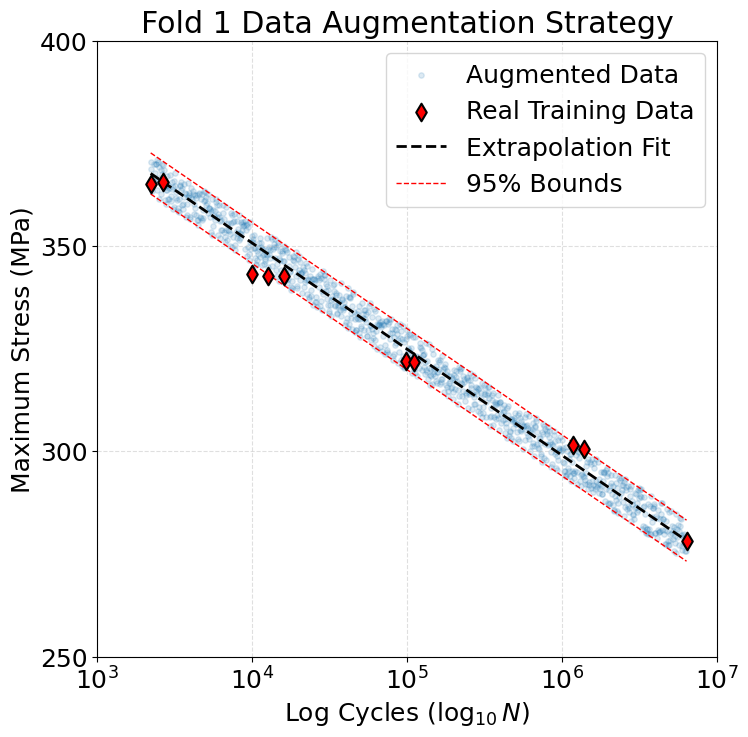

Visualizing Stress vs. Predicted Temperature for Fold 1...


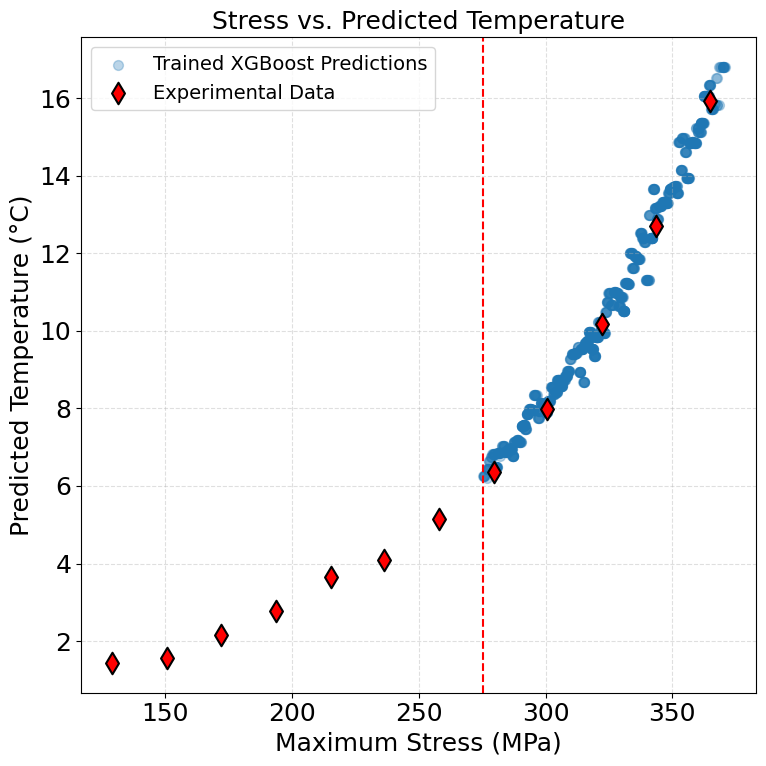

Fold 1/11 complete.


/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Fold 2/11 complete.


/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Fold 3/11 complete.


...

/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Fold 9/11 complete.


/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Fold 10/11 complete.
Fold 11/11 complete.


/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [40]:
ensemble_models, metrics_table = run_final_pipeline(df=df,
    xgb_model=model_xgb,
    best_k=11,        
    device=device,
    epochs=1000,         
    lr=0.002,
    lam_phys=0.1,
    do_plots_first_fold=True)

Generating Final Report for K=11 Ensemble...
------------------------------
MODEL PERFORMANCE REPORT
------------------------------
RMSE (Log Units):      0.1541
Avg Error Factor:      1.43x (Life prediction is within factor of 1.4)
Normalized RMSE:       4.46% of data range
R² Score:              0.9839
------------------------------
VERDICT: EXCELLENT (Within standard experimental scatter)


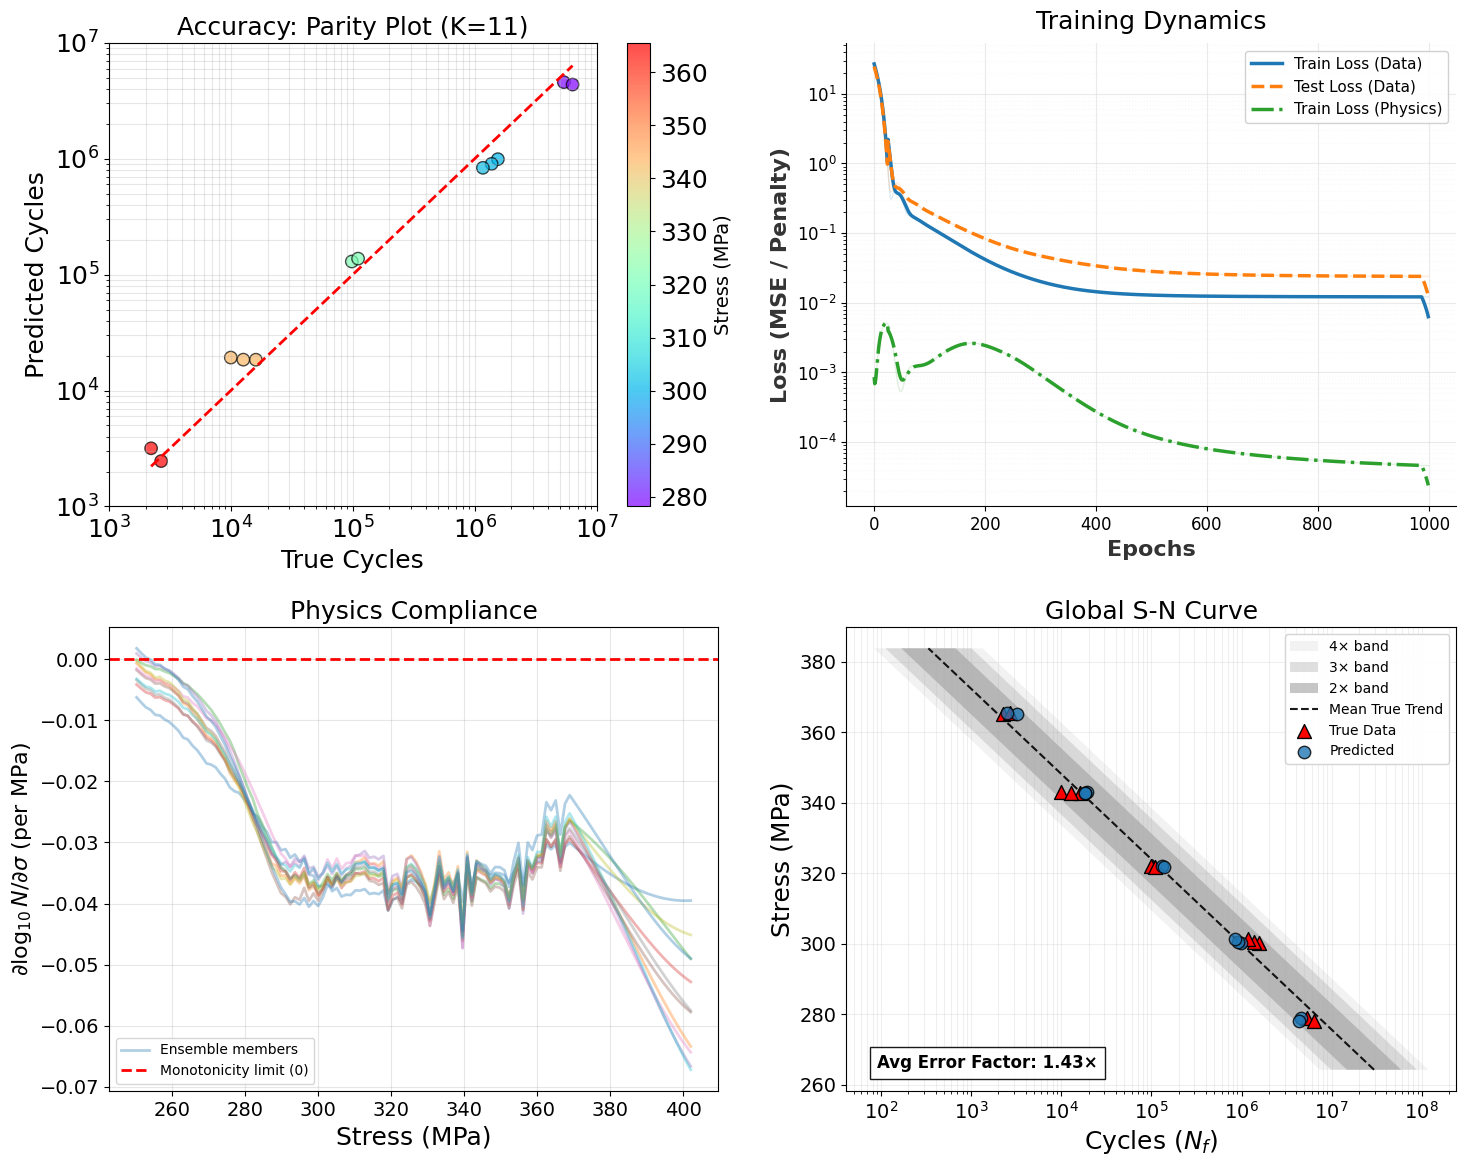

In [41]:
generate_final_report(df, ensemble_models, model_xgb, device=device, lam_phys=0.1)

In [42]:
def plot_sn_curve_with_bands_vibrant(df, ensemble_models, xgb_model, device='cpu'):
    """
    Generates a standalone S-N Curve plot with GRAYSCALE 2x, 3x, and 4x error bands.
    Opacity decreases from the outer band (4x) to the inner band (2x).
    """
    np.random.seed(42)
    k = len(ensemble_models)
    print(f"Generating Grayscale S-N Curve for K={k} Ensemble...")

    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    all_true, all_pred, all_stress = [], [], []

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(df)):
        test_fold = df.iloc[test_idx].copy()
        test_fold["Predicted Temperature"] = xgb_model.predict(test_fold[["Maximum stress"]])
        
        pack = ensemble_models[fold_idx]
        model, scaler = pack["model"], pack["scaler"]
        
        X_test = test_fold[["Maximum stress", "Predicted Temperature"]].values
        X_test_s = scaler.transform(X_test)
        X_test_t = torch.tensor(X_test_s, dtype=torch.float32, device=device)
        
        model.eval()
        with torch.no_grad():
            logN = model(X_test_t).cpu().numpy().flatten()
            
        all_true.extend(test_fold["Number of cycles"].values)
        all_pred.extend(10**logN)
        all_stress.extend(test_fold["Maximum stress"].values)

    np_true = np.array(all_true)
    np_pred = np.array(all_pred)
    np_stress = np.array(all_stress)
    regr = LinearRegression()
    regr.fit(np_stress.reshape(-1, 1), np.log10(np_true))
    
    smooth_stress = np.linspace(np_stress.min()*0.95, np_stress.max()*1.05, 100)
    trend_log_smooth = regr.predict(smooth_stress.reshape(-1, 1))
    trend_cycles_smooth = 10**trend_log_smooth
    
    factors = [4, 3, 2] 
    colors = ['#E0E0E0', '#C0C0C0', '#A0A0A0'] 
    labels = ['4x Factor (Outer)', '3x Factor', '2x Factor (Inner)']
    alphas = [0.4, 0.5, 0.6]

    plt.figure(figsize=(10, 7))
    
    for factor, color, alpha, label in zip(factors, colors, alphas, labels):
        upper_band = trend_cycles_smooth * factor
        lower_band = trend_cycles_smooth / factor
        plt.fill_betweenx(smooth_stress, lower_band, upper_band, 
                          color=color, alpha=alpha, label=label, edgecolor='none')

    plt.plot(trend_cycles_smooth, smooth_stress, 'k--', alpha=0.8, label='Mean True Trend', linewidth=1.5)


    plt.scatter(np_true, np_stress, marker='d', color='red', s=80, label='True Data', zorder=10, linewidth=1.5, edgecolors="k")
    plt.scatter(np_pred, np_stress, marker='o', color='blue', s=60, label='Predicted', alpha=1.0, zorder=11, edgecolors='k', linewidth=0.5)

    log_true = np.log10(np_true)
    log_pred = np.log10(np_pred)
    rmse_log = np.sqrt(np.mean((log_true - log_pred)**2))
    avg_error_factor = 10**rmse_log

    plt.xscale('log')
    plt.xlabel('Cycles ($N_f$)', fontsize=12, fontweight='bold')
    plt.ylabel('Stress (MPa)', fontsize=12, fontweight='bold')
    plt.title('Global S-N Curve with Grayscale Scatter Bands', fontsize=14, fontweight='bold')
    plt.xlim(1e2, 1e8)
    plt.ylim(df["Maximum stress"].min()-20, df["Maximum stress"].max()+20)

    plt.grid(True, which="both", ls="-", color='lightgrey', alpha=0.4)

    legend = plt.legend(loc='upper right', framealpha=1, facecolor='white', edgecolor='black', fontsize=10, shadow=True)
    frame = legend.get_frame()
    frame.set_linewidth(1.0)

    plt.figtext(0.15, 0.15, 
                f"Avg Error Factor: {avg_error_factor:.2f}x", 
                bbox={'facecolor':'white', 'alpha':1.0, 'pad':6, 'edgecolor':'black', 'boxstyle':'round,pad=0.5'}, 
                fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

Generating Grayscale S-N Curve for K=11 Ensemble...


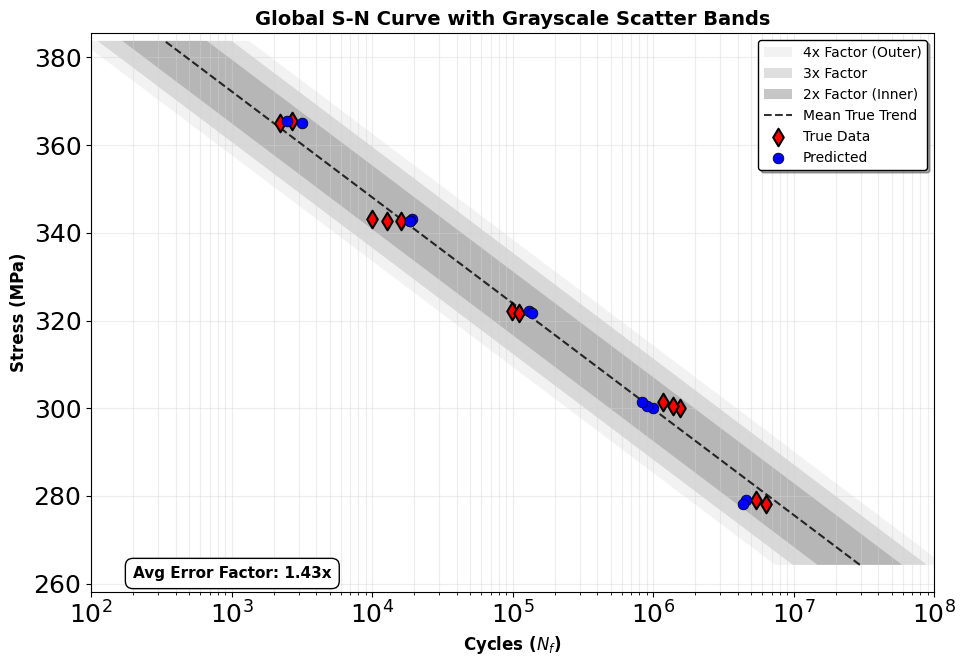

In [43]:
plot_sn_curve_with_bands_vibrant(df, ensemble_models, model_xgb, device=device)

Ghost Training function 

We try to implement and create a graph overlaying both models, one trained without the physics loss and another trained on physics loss 

In [44]:
def train_ghost_model(df, xgb_model):
    print("Training 'Ghost' Model (Physics Weight = 0.0)...")
    
    kf = KFold(n_splits=2, shuffle=True, random_state=42) 
    train_idx, test_idx = next(kf.split(df)) 
    
    train_fold = df.iloc[train_idx].copy()
    
    train_aug = augment_training_data(train_fold)
    train_aug["Predicted Temperature"] = xgb_model.predict(train_aug[["Maximum stress"]])
    
    X_train = train_aug[["Maximum stress", "Predicted Temperature"]].values
    y_train = train_aug["log cycles"].values.reshape(-1, 1)
    
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_tr_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
    y_tr_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    
    # 3. Train WITHOUT Physics
    model = LifeNet(hidden=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    
    model.train()
    for _ in range(1000):
        optimizer.zero_grad()
        pred = model(X_tr_t)
        loss = nn.MSELoss()(pred, y_tr_t) + 0.0 * physics_loss(model, X_tr_t) 
        loss.backward()
        optimizer.step()
        
    return {"model": model, "scaler": scaler}

ghost_package = train_ghost_model(df, model_xgb)

Training 'Ghost' Model (Physics Weight = 0.0)...


Comparing Derivatives: PINN vs Ghost...


<Figure size 800x500 with 0 Axes>

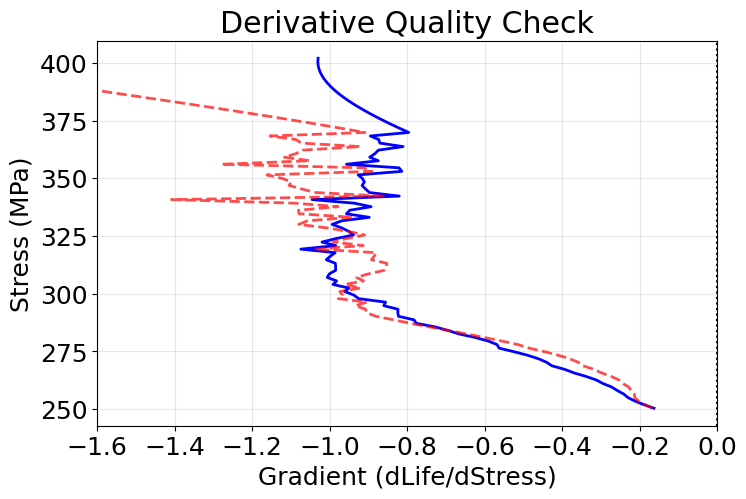

In [45]:
def compare_model_derivatives(df,xgb_model,pinn_package, ghost_package, device):
    print("Comparing Derivatives: PINN vs Ghost...")
    
    # 1. Setup Grid
    min_stress = df["Maximum stress"].min()
    max_stress = df["Maximum stress"].max()
    
    stress_range = np.linspace(min_stress * 0.9, max_stress * 1.1, 100).reshape(-1, 1)
    temp_df = pd.DataFrame(stress_range, columns=["Maximum stress"])
    temp_range = xgb_model.predict(temp_df).reshape(-1, 1)
    X_raw = np.column_stack([stress_range, temp_range])
    
    # 2. Get Derivatives for PINN
    model_p, scaler_p = pinn_package[0]["model"], pinn_package[0]["scaler"]
    X_s_p = scaler_p.transform(X_raw)
    X_t_p = torch.tensor(X_s_p, dtype=torch.float32, device=device, requires_grad=True)
    
    model_p.eval()
    pred_p = model_p(X_t_p)
    grads_p = torch.autograd.grad(pred_p, X_t_p, torch.ones_like(pred_p), create_graph=False)[0]
    deriv_pinn = grads_p[:, 0].cpu().detach().numpy()
    
    # 3. Get Derivatives for Ghost
    model_g, scaler_g = ghost_package["model"], ghost_package["scaler"]
    X_s_g = scaler_g.transform(X_raw)
    X_t_g = torch.tensor(X_s_g, dtype=torch.float32, device=device, requires_grad=True)
    
    model_g.eval()
    pred_g = model_g(X_t_g)
    grads_g = torch.autograd.grad(pred_g, X_t_g, torch.ones_like(pred_g), create_graph=False)[0]
    deriv_ghost = grads_g[:, 0].cpu().detach().numpy()
    
    plt.figure(figsize=(8, 5))
    plt.figure(figsize=(8, 5))
    plt.plot(deriv_pinn, stress_range, 'b-', linewidth=2, label='PINN Derivative')
    plt.plot(deriv_ghost, stress_range, 'r--', linewidth=2, alpha=0.7, label='Ghost Derivative')
 
    plt.axvline(0, color='k', linestyle=':', label='Zero Line')
 
    plt.xlabel('Gradient (dLife/dStress)')
    plt.xlim(-1.6, 0)
    plt.ylabel('Stress (MPa)')
    plt.title('Derivative Quality Check')
    plt.grid(True, alpha=0.3)
    plt.show()

# Run it
compare_model_derivatives(df,model_xgb,ensemble_models, ghost_package, device)

In [46]:
def train_no_physics_model(df, xgb_model, k_folds=21):
    print(f"Training 'Pure Data' Model (Physics Weight = 0.0) using K={k_folds}...")
    
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    train_idx, test_idx = next(kf.split(df))
    
    train_fold = df.iloc[train_idx].copy()
    
    # Augment data
    train_aug = augment_training_data(train_fold)
    train_aug["Predicted Temperature"] = xgb_model.predict(train_aug[["Maximum stress"]])
    
    # Prepare Data
    X_train = train_aug[["Maximum stress", "Predicted Temperature"]].values
    y_train = train_aug["log cycles"].values.reshape(-1, 1)
    
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_tr_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
    y_tr_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    
    # Train
    model = LifeNet(hidden=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    criterion = nn.MSELoss()
    
    model.train()
    for _ in range(1000): 
        optimizer.zero_grad()
        pred = model(X_tr_t)
        
        loss = criterion(pred, y_tr_t)
        
        loss.backward()
        optimizer.step()
        
    return {"model": model, "scaler": scaler}

In [47]:
def visualize_predictions_comparison(df, pinn_ensemble, no_phys_package, xgb_model):
    print("Generating Prediction Overlay: PINN vs No-Physics...")
    
    pinn_model = pinn_ensemble[0]["model"]
    pinn_scaler = pinn_ensemble[0]["scaler"]
    
    np_model = no_phys_package["model"]
    np_scaler = no_phys_package["scaler"]
    
    min_stress = df["Maximum stress"].min() 
    max_stress = df["Maximum stress"].max() 
    
    stress_range = np.linspace(min_stress, max_stress, 200).reshape(-1, 1)
    
    temp_df = pd.DataFrame(stress_range, columns=["Maximum stress"])
    temp_pred = xgb_model.predict(temp_df).reshape(-1, 1)
    
    X_grid = np.column_stack([stress_range, temp_pred])
    
    # Predict: PINN
    X_pinn_s = pinn_scaler.transform(X_grid)
    X_pinn_t = torch.tensor(X_pinn_s, dtype=torch.float32, device=device)
    pinn_model.eval()
    with torch.no_grad():
        logN_pinn = pinn_model(X_pinn_t).cpu().numpy().flatten()

    # Predict: No-Physics
    X_np_s = np_scaler.transform(X_grid)
    X_np_t = torch.tensor(X_np_s, dtype=torch.float32, device=device)
    np_model.eval()
    with torch.no_grad():
        logN_np = np_model(X_np_t).cpu().numpy().flatten()
        
    # --- PLOT ---
    plt.figure(figsize=(10, 7))
    
    # 1. Real Data
    plt.scatter(df["Number of cycles"], df["Maximum stress"], 
                c='red', marker='d', s=80, label='Experimental Data', zorder=10, edgecolors="k")
    
    # 2. PINN Prediction
    plt.plot(10**logN_pinn, stress_range, 
             'b-', linewidth=2.5, label='PINN (With Physics)')
    
    # 3. No-Physics Prediction
    plt.plot(10**logN_np, stress_range, 
             'k--', linewidth=2, label='Standard NN (No Physics)')
    
    plt.xscale('log')
    plt.xlabel('Cycles to Failure ($N_f$)', fontsize=12)
    plt.ylabel('Stress (MPa)', fontsize=12)
    plt.title('Impact of Physics Loss on Predictions', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, which="both", alpha=0.3)
    plt.xlim(1e2, 1e8)
    plt.ylim(260,385)
    plt.tight_layout()
    plt.show()

The following scatter plot shows how the predictions look like. The jitters or wobbly line we see is from the temperature prediction, as we used the xgboost model to predict the temp for correspomdomg stress values. Number of cycles is highly sensitive to the temperature. And also, xgboost does not give a smooth curve, rather it gives a stepwise graph as we can observe from the plot as well

Training 'Pure Data' Model (Physics Weight = 0.0) using K=11...
Generating Prediction Overlay: PINN vs No-Physics...


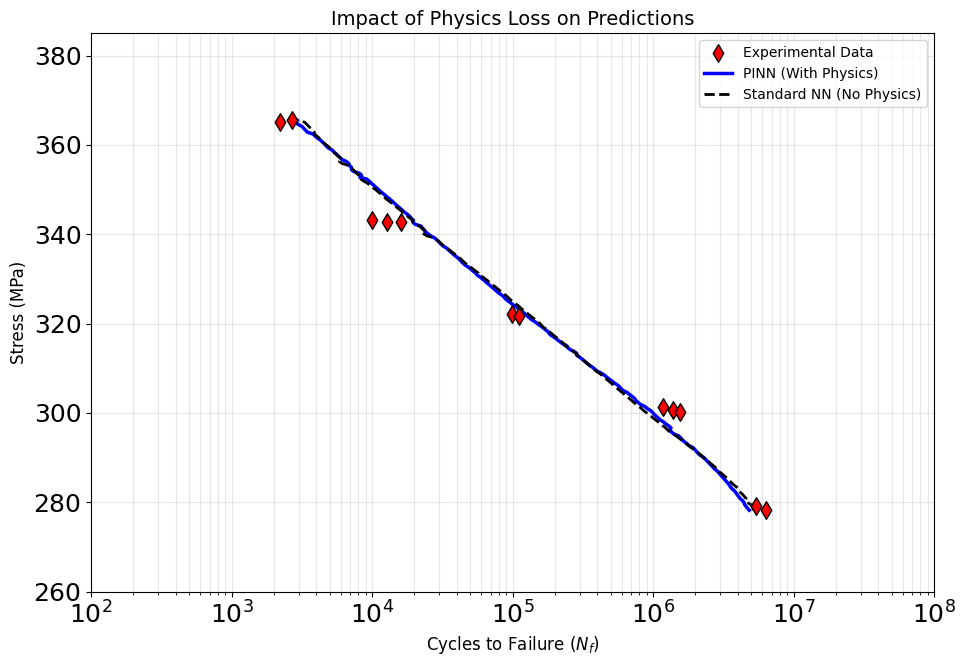

In [48]:
# 1. Train the single "No Physics" model
no_phys_model = train_no_physics_model(df, model_xgb, k_folds=11)

# 2. Visualize the difference
visualize_predictions_comparison(df, ensemble_models, no_phys_model, model_xgb)

Benchmark Comparsion with other baseline models with the same input-output feature mapping

In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ),

    "SVR (RBF)": make_pipeline(
        StandardScaler(),
        SVR(C=10, epsilon=0.25, kernel='rbf')
    ),

    "SVR (RBF V2)": make_pipeline(
        StandardScaler(),
        SVR(C=1, epsilon=0.9, kernel='rbf')
    ),

    "SVR (POLY)": make_pipeline(
        StandardScaler(),
        SVR(C=1, epsilon=0.5, kernel='poly')
    ),

    "MLP": MLPRegressor(
        hidden_layer_sizes=(32,16),
        max_iter=2000,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [ ]:
results = []

global_predictions = {}

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

kf = KFold(n_splits=11, shuffle=True, random_state=42)

for model_name, model in models.items():

    all_true = []
    all_pred = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(df)):

        train_df = df.iloc[train_idx].copy()
        test_df = df.iloc[test_idx].copy()

        # Temperature prediction
        train_df["Predicted Temperature"] = model_xgb.predict(
            train_df[["Maximum stress"]]
        )

        test_df["Predicted Temperature"] = model_xgb.predict(
            test_df[["Maximum stress"]]
        )

        X_train = train_df[[
            "Maximum stress",
            "Predicted Temperature"
        ]]

        X_test = test_df[[
            "Maximum stress",
            "Predicted Temperature"
        ]]

        y_train = train_df["log cycles"]
        y_test = test_df["log cycles"]

        # Train
        model.fit(X_train, y_train)

        # Predict
        preds = model.predict(X_test)

        # Store globally
        all_true.extend(y_test.values)
        all_pred.extend(preds)

    # Convert
    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    # GLOBAL metrics
    mse = mean_squared_error(all_true, all_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(all_true, all_pred)
    r2 = r2_score(all_true, all_pred)

    results.append({
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    global_predictions[model_name] = {
        "y_true": all_true,
        "y_pred": all_pred
    }

all_true_pinn = []
all_pred_pinn = []

kf = KFold(n_splits=11, shuffle=True, random_state=42)

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(df)):

    test_fold = df.iloc[test_idx].copy()

    test_fold["Predicted Temperature"] = model_xgb.predict(
        test_fold[["Maximum stress"]]
    )

    pack = ensemble_models[fold_idx]

    model = pack["model"]
    scaler = pack["scaler"]

    X_test = test_fold[[
        "Maximum stress",
        "Predicted Temperature"
    ]].values

    X_test_s = scaler.transform(X_test)

    X_test_t = torch.tensor(
        X_test_s,
        dtype=torch.float32,
        device=device
    )

    model.eval()

    with torch.no_grad():
        preds = model(X_test_t).cpu().numpy().flatten()

    y_true = test_fold["log cycles"].values

    all_true_pinn.extend(y_true)
    all_pred_pinn.extend(preds)

# Convert
all_true_pinn = np.array(all_true_pinn)
all_pred_pinn = np.array(all_pred_pinn)

# GLOBAL PINN metrics
mse = mean_squared_error(all_true_pinn, all_pred_pinn)
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_true_pinn, all_pred_pinn)
r2 = r2_score(all_true_pinn, all_pred_pinn)

results.append({
    "Model": "PINN",
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2
})

global_predictions["PINN"] = {
    "y_true": all_true_pinn,
    "y_pred": all_pred_pinn
}

In [66]:
results_df = pd.DataFrame(results)

results_df = results_df.round(4)

print(results_df)

           Model     MSE    RMSE     MAE      R2
0  Random Forest  0.0471  0.2171  0.1858  0.9680
1      SVR (RBF)  0.0450  0.2120  0.1788  0.9695
2   SVR (RBF V2)  0.4220  0.6497  0.5925  0.7132
3     SVR (POLY)  0.5375  0.7332  0.6583  0.6347
4            MLP  2.3171  1.5222  0.9000 -0.5746
5        XGBoost  0.1591  0.3989  0.2521  0.8919
6           PINN  0.0237  0.1541  0.1395  0.9839


Sensitivity Analysis for Data Augmentation 

In [ ]:
def augment_training_data_analysis(
    df,
    n_aug=1000,
    variation_pct=0.05,
    random_state=42
):
    """
    Generates synthetic fatigue data around a stress-life trend.
    
    variation_pct:
        Relative stress perturbation
        Example:
            0.05 = ±5%
    """

    np.random.seed(random_state)

    # Extreme points
    p_min = df.loc[df["Maximum stress"].idxmin()]
    p_max = df.loc[df["Maximum stress"].idxmax()]

    # Linear trend
    slope = (
        (p_max["Maximum stress"] - p_min["Maximum stress"]) /
        (p_max["log cycles"] - p_min["log cycles"])
    ) if p_max["log cycles"] != p_min["log cycles"] else 0

    intercept = (
        p_max["Maximum stress"]
        - slope * p_max["log cycles"]
    )

    # Synthetic cycles
    x_synth = np.linspace(
        df["log cycles"].min(),
        df["log cycles"].max(),
        n_aug
    )

    # Stress line
    y_line = slope * x_synth + intercept

    # Relative noise
    noise = variation_pct * y_line

    y_synth = np.random.uniform(
        y_line - noise,
        y_line + noise
    )

    df_aug = pd.DataFrame({
        "log cycles": x_synth,
        "Maximum stress": y_synth,
        "Number of cycles": 10**x_synth,
        "Source": "augmented",
        "UTS": 430,
        "Maximum stress(%UTS)": (y_synth * 100) / 430
    })

    return pd.concat([df, df_aug], ignore_index=True)

In [68]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler


def run_final_pipeline(
    df,
    xgb_model,
    best_k=2,
    device=None,
    epochs=1000,
    lr=0.002,
    lam_phys=0.1,
    n_aug=1000,
    variation_pct=0.05,

    do_plots_first_fold=True
):

    if device is None:
        device = torch.device(
            "cuda" if torch.cuda.is_available()
            else "mps" if torch.backends.mps.is_available()
            else "cpu"
        )

    print(f"\nTraining Final Ensemble with K={best_k}")
    print(f"Augmentation Points: {n_aug}")
    print(f"Variation Percentage: {variation_pct*100:.1f}%")

    kf = KFold(
        n_splits=best_k,
        shuffle=True,
        random_state=42
    )

    ensemble_models = []
    metrics_rows = []

    # NEW: global storage
    global_true = []
    global_pred = []

    # ==========================================================
    # K-FOLD LOOP
    # ==========================================================
    for fold, (train_idx, test_idx) in enumerate(kf.split(df)):

        print(f"\nFold {fold+1}/{best_k}")

        # ------------------------------------------------------
        # 1) SPLIT
        # ------------------------------------------------------
        train_fold = df.iloc[train_idx].copy()
        test_fold = df.iloc[test_idx].copy()

        train_fold["Source"] = "real"

        if "Run Out" in train_fold.columns:
            train_fold = train_fold[
                train_fold["Run Out"] != "yes"
            ].copy()

        if "Run Out" in test_fold.columns:
            test_fold = test_fold[
                test_fold["Run Out"] != "yes"
            ].copy()

        # ------------------------------------------------------
        # 2) AUGMENT TRAINING DATA
        # ------------------------------------------------------
        train_aug = augment_training_data_analysis(
            train_fold,
            n_aug=n_aug,
            variation_pct=variation_pct
        )

        if "Run Out" in train_aug.columns:
            train_aug = train_aug[
                train_aug["Run Out"] != "yes"
            ].copy()

        # ------------------------------------------------------
        # OPTIONAL VISUALIZATION
        # ------------------------------------------------------
        if do_plots_first_fold and fold == 0:

            print("Visualizing Augmentation...")

            visualize_fold_augmentation(
                train_aug,
                fold
            )

        # ------------------------------------------------------
        # 3) TEMPERATURE PREDICTION
        # ------------------------------------------------------
        train_aug["Predicted Temperature"] = xgb_model.predict(
            train_aug[["Maximum stress"]]
        )

        if not test_fold.empty:

            test_fold["Predicted Temperature"] = xgb_model.predict(
                test_fold[["Maximum stress"]]
            )

        if do_plots_first_fold and fold == 0:

            print("Visualizing Stress vs Temperature...")

            plot_augmented_stress_vs_temp(train_aug)

        # ------------------------------------------------------
        # 4) PREPARE TRAIN DATA
        # ------------------------------------------------------
        X_train = train_aug[
            ["Maximum stress", "Predicted Temperature"]
        ].values

        y_train = train_aug[
            "log cycles"
        ].values.reshape(-1, 1)

        scaler = StandardScaler()

        X_train_s = scaler.fit_transform(X_train)

        X_tr_t = torch.tensor(
            X_train_s,
            dtype=torch.float32,
            device=device
        )

        y_tr_t = torch.tensor(
            y_train,
            dtype=torch.float32,
            device=device
        )

        X_tr_t.requires_grad_(True)

        # ------------------------------------------------------
        # 5) PREPARE TEST DATA
        # ------------------------------------------------------
        X_te_t_val = None
        y_te_t_val = None

        if not test_fold.empty:

            X_test_val = test_fold[
                ["Maximum stress", "Predicted Temperature"]
            ].values

            y_test_val = test_fold[
                "log cycles"
            ].values.reshape(-1, 1)

            X_test_val_s = scaler.transform(X_test_val)

            X_te_t_val = torch.tensor(
                X_test_val_s,
                dtype=torch.float32,
                device=device
            )

            y_te_t_val = torch.tensor(
                y_test_val,
                dtype=torch.float32,
                device=device
            )

        # ------------------------------------------------------
        # 6) TRAIN PINN
        # ------------------------------------------------------
        model = LifeNet(hidden=64).to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr
        )

        hist_d = []
        hist_p = []
        hist_test = []

        model.train()

        for ep in range(epochs):

            optimizer.zero_grad()

            pred = model(X_tr_t)

            # Data loss
            loss_d = nn.MSELoss()(pred, y_tr_t)

            # Physics loss
            loss_p = physics_loss(model, X_tr_t)

            # Total loss
            loss = loss_d + lam_phys * loss_p

            loss.backward()

            optimizer.step()

            # Store histories
            hist_d.append(loss_d.item())
            hist_p.append(loss_p.item())

            # Validation loss
            if X_te_t_val is not None:

                model.eval()

                with torch.no_grad():

                    pred_val = model(X_te_t_val)

                    loss_val = nn.MSELoss()(
                        pred_val,
                        y_te_t_val
                    )

                    hist_test.append(loss_val.item())

                model.train()

            else:
                hist_test.append(np.nan)

        # ------------------------------------------------------
        # 7) TRAIN METRICS
        # ------------------------------------------------------
        model.eval()

        with torch.no_grad():

            yhat_train = model(
                X_tr_t
            ).cpu().numpy().reshape(-1)

        ytrue_train = y_train.reshape(-1)

        train_mse = mean_squared_error(
            ytrue_train,
            yhat_train
        )

        train_rmse = np.sqrt(train_mse)

        train_mae = mean_absolute_error(
            ytrue_train,
            yhat_train
        )

        train_r2 = r2_score(
            ytrue_train,
            yhat_train
        )

        # ------------------------------------------------------
        # 8) TEST METRICS
        # ------------------------------------------------------
        if test_fold.empty:

            test_mse = np.nan
            test_rmse = np.nan
            test_mae = np.nan
            test_r2 = np.nan

        else:

            with torch.no_grad():

                yhat_test = model(
                    X_te_t_val
                ).cpu().numpy().reshape(-1)

            y_test = y_te_t_val.cpu().numpy().reshape(-1)

            test_mse = mean_squared_error(
                y_test,
                yhat_test
            )

            test_rmse = np.sqrt(test_mse)

            test_mae = mean_absolute_error(
                y_test,
                yhat_test
            )

            test_r2 = r2_score(
                y_test,
                yhat_test
            )

            # GLOBAL STORAGE
            global_true.extend(y_test)
            global_pred.extend(yhat_test)

        # ------------------------------------------------------
        # STORE MODEL
        # ------------------------------------------------------
        ensemble_models.append({

            "model": model,
            "scaler": scaler,

            # augmentation parameters
            "n_aug": n_aug,
            "variation_pct": variation_pct,

            # histories
            "history_data": hist_d,
            "history_phys": hist_p,
            "history_test": hist_test,

            # train data
            "train_stress": train_aug["Maximum stress"].values,
            "train_temp": train_aug["Predicted Temperature"].values,
            "train_logN": train_aug["log cycles"].values,

            # metrics
            "train_mse": train_mse,
            "train_rmse": train_rmse,
            "train_mae": train_mae,
            "train_r2": train_r2,

            "test_mse": test_mse,
            "test_rmse": test_rmse,
            "test_mae": test_mae,
            "test_r2": test_r2,

            # metadata
            "fold_index": fold,
            "lam_phys": lam_phys,
            "epochs": epochs,
            "lr": lr
        })

        # ------------------------------------------------------
        # STORE FOLD METRICS
        # ------------------------------------------------------
        metrics_rows.append({

            "fold": fold + 1,

            "n_aug": n_aug,
            "variation_pct": variation_pct,

            "train_MSE(logN)": train_mse,
            "train_RMSE(logN)": train_rmse,
            "train_MAE(logN)": train_mae,
            "train_R2(logN)": train_r2,

            "test_MSE(logN)": test_mse,
            "test_RMSE(logN)": test_rmse,
            "test_MAE(logN)": test_mae,
            "test_R2(logN)": test_r2
        })

    # ==========================================================
    # PER-FOLD TABLE
    # ==========================================================
    metrics_table = pd.DataFrame(metrics_rows)

    mean_row = {"fold": "mean"}
    std_row = {"fold": "std"}

    for col in metrics_table.columns[1:]:

        mean_row[col] = metrics_table[col].mean()

        std_row[col] = (
            metrics_table[col].std(ddof=1)
            if len(metrics_table) > 1
            else 0.0
        )

    metrics_table = pd.concat(
        [
            metrics_table,
            pd.DataFrame([mean_row, std_row])
        ],
        ignore_index=True
    )

    # ==========================================================
    # GLOBAL METRICS
    # ==========================================================
    global_true = np.array(global_true)
    global_pred = np.array(global_pred)

    global_mse = mean_squared_error(
        global_true,
        global_pred
    )

    global_rmse = np.sqrt(global_mse)

    global_mae = mean_absolute_error(
        global_true,
        global_pred
    )

    global_r2 = r2_score(
        global_true,
        global_pred
    )

    global_metrics = {

        "GLOBAL_MSE": global_mse,
        "GLOBAL_RMSE": global_rmse,
        "GLOBAL_MAE": global_mae,
        "GLOBAL_R2": global_r2,

        "n_aug": n_aug,
        "variation_pct": variation_pct
    }

    print("\n==============================")
    print("GLOBAL PERFORMANCE")
    print("==============================")
    print(f"GLOBAL RMSE: {global_rmse:.4f}")
    print(f"GLOBAL MAE : {global_mae:.4f}")
    print(f"GLOBAL R²  : {global_r2:.4f}")
    print("==============================")

    return (
        ensemble_models,
        metrics_table,
        global_metrics
    )

In [ ]:
sensitivity_results = []

n_aug_values = [100, 250, 500, 750, 1000]
variation_values = [0.05, 0.075]

for n_aug in n_aug_values:

    for variation in variation_values:

        print("=" * 50)
        print(f"Running: n_aug={n_aug}, variation={variation}")
        print("=" * 50)

        # Run pipeline
        ensemble_models, metrics_table, global_metrics = run_final_pipeline(

            df=df,
            xgb_model=model_xgb,

            best_k=11,
            device=device,

            epochs=1000,
            lr=0.002,
            lam_phys=0.1,

            # sensitivity parameters
            n_aug=n_aug,
            variation_pct=variation,

            do_plots_first_fold=False
        )

        # Store results
        sensitivity_results.append({

            "n_aug": n_aug,
            "variation_pct": variation,

            "GLOBAL_MSE": global_metrics["GLOBAL_MSE"],
            "GLOBAL_RMSE": global_metrics["GLOBAL_RMSE"],
            "GLOBAL_MAE": global_metrics["GLOBAL_MAE"],
            "GLOBAL_R2": global_metrics["GLOBAL_R2"]
        })

In [ ]:
sensitivity_df = pd.DataFrame(sensitivity_results)

sensitivity_df = sensitivity_df.sort_values(
    by=["variation_pct", "n_aug"]
)

print(sensitivity_df)